# Análise Exploratória dos dados

In [354]:
%%capture
!pip install xgboost catboost scikit-learn matplotlib seaborn pandas numpy ngboost

In [355]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score, silhouette_score
)
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GroupKFold
import os, shap, multiprocessing, subprocess
from sklearn.cluster import HDBSCAN, KMeans
from catboost import CatBoostRegressor
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
from ngboost import NGBRegressor
from xgboost import XGBRegressor
from collections import Counter
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.base import clone
from tqdm.notebook import tqdm
import seaborn as sns
import pandas as pd
import numpy as np

In [356]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [357]:
base_dir = '/content/drive/MyDrive/supervised-learning-studies/projeto'
file_path = os.path.join(base_dir, 'BD_filerCalcario_versao_1.xlsx')
file = pd.ExcelFile(file_path)
base_dir = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
print(file.sheet_names)

['BD_ML_Resis', 'BD_ML_Slump_1', 'Dicionario_Variaveis']


In [358]:
df_resistencia = file.parse('BD_ML_Resis')
df_resistencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Autores/ano                  599 non-null    object 
 1   ID_Mistura                   599 non-null    object 
 2   Tipo_Cimento_Classe          599 non-null    object 
 3   Massa_Esp_Cimento_g_cm3      462 non-null    float64
 4   Finura_Cimento_Blaine_m2_kg  414 non-null    float64
 5   Massa_Esp_Filer_g_cm3        358 non-null    float64
 6   Massa_Esp_Areia_g_cm3        262 non-null    float64
 7   Massa_Esp_Brita_g_cm3        273 non-null    float64
 8   Cimento_kg_m3                599 non-null    float64
 9   Filer_Calcario_kg_m3         599 non-null    float64
 10  Agua_kg_m3                   599 non-null    float64
 11  Agregado_Miudo_Total_kg_m3   599 non-null    float64
 12  Agregado_Graudo_Total_kg_m3  599 non-null    float64
 13  Superplastificante_k

In [359]:
df_resistencia.Tipo_Cimento_Classe.sort_values(ascending=False).value_counts()

,count
Tipo_Cimento_Classe,
"CEM I 42,5 N",175
ASTM C 150 Type I,75
CP-V ARI,51
Type I OPC,50
"CEM I 42,5 R",41
OPC,40
Type I Portland,24
"P,I 42,5 (CEM I)",21
OPC (ASTM C150),21


In [360]:
autores = df_resistencia['Autores/ano'].unique()

for autor in autores:
    df_autor = df_resistencia[df_resistencia['Autores/ano'] == autor]
    print(f"{autor}, Número de amostras: {len(df_autor)} | {df_autor.shape[0]/len(df_resistencia)*100:.2f}%")

Dos Santos et al, 2024, Número de amostras: 15 | 2.50%
Guemmadi et al, 2009, Número de amostras: 26 | 4.34%
Meddah et al 2014, Número de amostras: 175 | 29.22%
A Morzouki 2016, Número de amostras: 35 | 5.84%
Bentz et al, 2015, Número de amostras: 11 | 1.84%
Feltrin 2018, Número de amostras: 36 | 6.01%
Gyu Don Moon 2017, Número de amostras: 24 | 4.01%
Hieu T Cam 2010, Número de amostras: 12 | 2.00%
Md Jahidul Islam 2025, Número de amostras: 15 | 2.50%
Diab et al, (2016), Número de amostras: 24 | 4.01%
Mohammed e Al-Numan (2024), Número de amostras: 15 | 2.50%
Leeuwen et al, (2016), Número de amostras: 50 | 8.35%
Ramezanianpour et al. (2009), Número de amostras: 75 | 12.52%
Bayan 2018, Número de amostras: 25 | 4.17%
Bonavetti et al. (2000)., Número de amostras: 9 | 1.50%
Tsivilis et al. (2003), Número de amostras: 10 | 1.67%
Sun e Chen 2018, Número de amostras: 21 | 3.51%
Abdul-Ghani et al, 2019, Número de amostras: 21 | 3.51%


In [361]:
dos_santos_mask = df_resistencia['Autores/ano'] == 'Dos Santos et al, 2024'
df_resistencia = df_resistencia[~dos_santos_mask]

In [362]:
df_resistencia.groupby("Autores/ano")['ID_Mistura'].nunique().sort_values(ascending=False)

,ID_Mistura
Autores/ano,
"Guemmadi et al, 2009",26
Meddah et al 2014,25
Ramezanianpour et al. (2009),15
Feltrin 2018,12
"Leeuwen et al, (2016)",10
Gyu Don Moon 2017,8
A Morzouki 2016,7
Sun e Chen 2018,7
"Abdul-Ghani et al, 2019",7


In [363]:
classe_encoder = LabelEncoder()
df_resistencia['cod_classe'] = classe_encoder.fit_transform(df_resistencia['Tipo_Cimento_Classe'])
df_resistencia['cod_classe'].value_counts()

,count
cod_classe,
6,175
0,75
17,50
7,41
13,40
10,36
18,24
15,21
14,21


/tmp/ipykernel_19118/1906372192.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


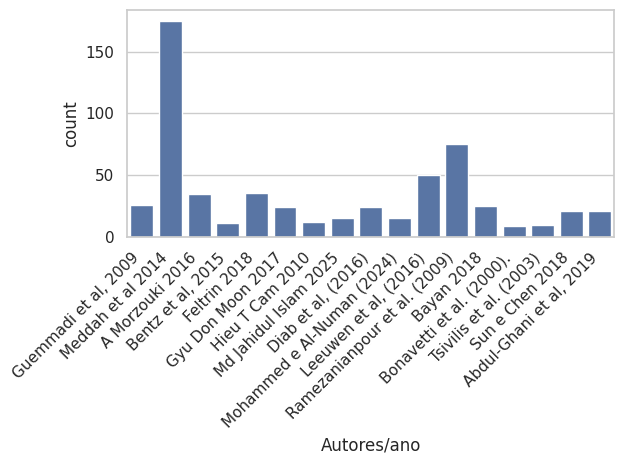

In [364]:
ax = sns.countplot(x='Autores/ano', data=df_resistencia)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

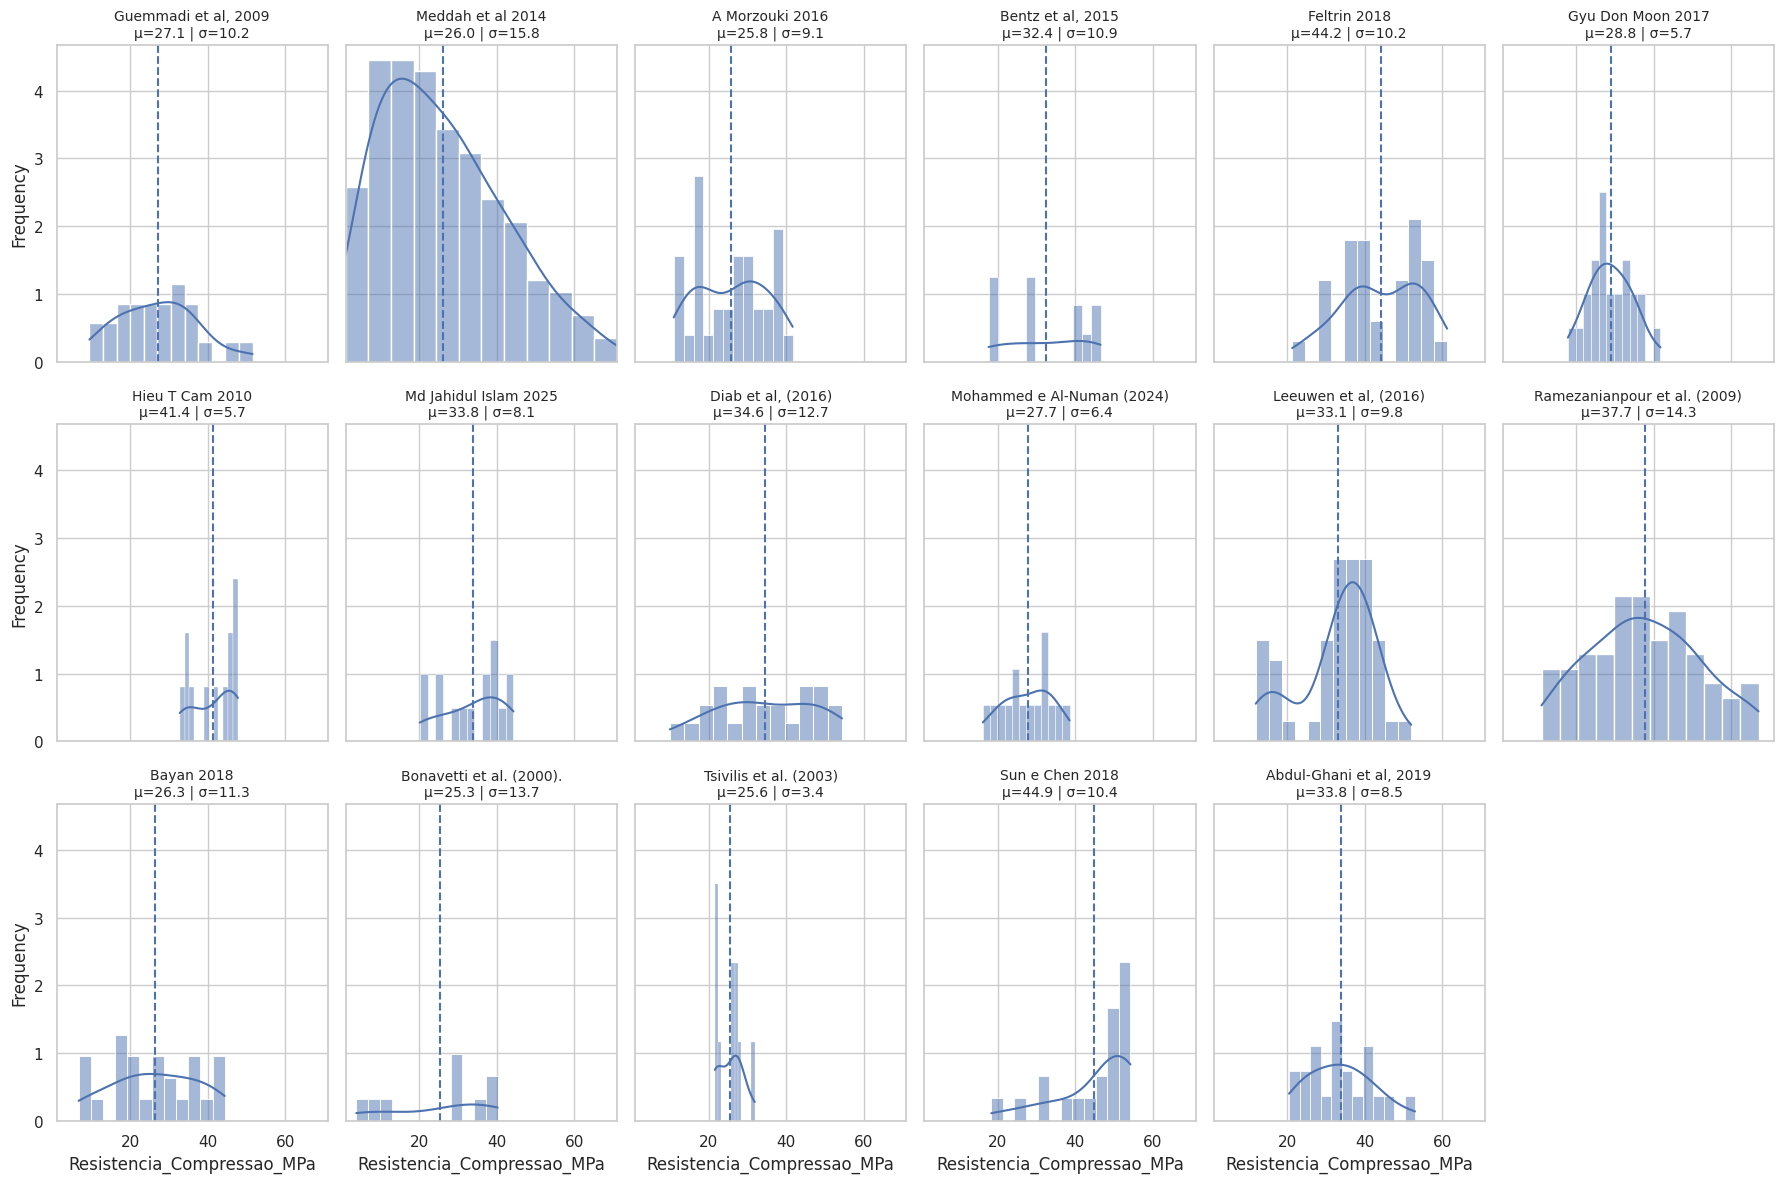

In [365]:
sns.set_style("whitegrid")
autores = df_resistencia['Autores/ano'].unique()
fig, axes = plt.subplots(
    nrows=3,
    ncols=int(np.ceil(len(autores) / 3)),
    figsize=(18, 4*3),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

xmin = df_resistencia['Resistencia_Compressao_MPa'].min()
xmax = df_resistencia['Resistencia_Compressao_MPa'].max()

for i, autor in enumerate(autores):

    df_autor = df_resistencia[
        df_resistencia['Autores/ano'] == autor
    ]
    media = df_autor['Resistencia_Compressao_MPa'].mean()
    std = df_autor['Resistencia_Compressao_MPa'].std()
    sns.histplot(
        data=df_autor,
        x='Resistencia_Compressao_MPa',
        bins=12,
        kde=True,
        stat='frequency',
        ax=axes[i]
    )
    axes[i].axvline(
        media,
        linestyle='--'
    )
    axes[i].set_title(
        f'{autor}\nμ={media:.1f} | σ={std:.1f}',
        fontsize=10
    )
    axes[i].set_xlim(xmin, xmax)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [366]:
columns = df_resistencia.columns

target_list = {'Resistencia_Compressao_MPa', 'Relacao_Agua_Cimento', 'Relacao_Agua_Aglomerante',
               'Superplastificante_kg_m3', 'Filer_Calcario_kg_m3', 'Agua_kg_m3', 'Cimento_kg_m3',
               'Agregado_Graudo_Total_kg_m3', 'Agregado_Miudo_Total_kg_m3'}

outliers_idx = {}
for column in target_list:
    data = df_resistencia[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_idx[column] = data[(data < lower_bound) | (data > upper_bound)].index.tolist()
    if outliers_idx[column]:
        print(f"{column}: {len(outliers_idx[column])} outliers")
        print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
        for idx in sorted(outliers_idx[column], key=lambda x: data[x], reverse=True):  # Mostrar até 5 outliers
            print(f"  Index: {idx}, Value: {data[idx]}")
        print()

Agregado_Graudo_Total_kg_m3: 25 outliers
Q1: 1018.0, Q3: 1200.0, IQR: 182.0, Lower Bound: 745.0, Upper Bound: 1473.0
  Index: 488, Value: 740.8
  Index: 489, Value: 740.8
  Index: 490, Value: 740.8
  Index: 491, Value: 740.8
  Index: 492, Value: 740.8
  Index: 493, Value: 738.7
  Index: 494, Value: 738.7
  Index: 495, Value: 738.7
  Index: 496, Value: 738.7
  Index: 497, Value: 738.7
  Index: 498, Value: 736.6
  Index: 499, Value: 736.6
  Index: 500, Value: 736.6
  Index: 501, Value: 736.6
  Index: 502, Value: 736.6
  Index: 503, Value: 734.5
  Index: 504, Value: 734.5
  Index: 505, Value: 734.5
  Index: 506, Value: 734.5
  Index: 507, Value: 734.5
  Index: 508, Value: 732.4
  Index: 509, Value: 732.4
  Index: 510, Value: 732.4
  Index: 511, Value: 732.4
  Index: 512, Value: 732.4

Agregado_Miudo_Total_kg_m3: 40 outliers
Q1: 670.0, Q3: 798.0, IQR: 128.0, Lower Bound: 478.0, Upper Bound: 990.0
  Index: 373, Value: 1074.0
  Index: 374, Value: 1074.0
  Index: 375, Value: 1074.0
  Index: 3

In [367]:
# 1. Imputação inteligente: Preenche o Blaine vazio com a mediana da sua respectiva Classe
df_resistencia['Finura_Cimento_Blaine_m2_kg'] = df_resistencia.groupby('Classe_Cim_OpA')['Finura_Cimento_Blaine_m2_kg'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Rede de segurança: Se uma classe inteira não tiver nenhum dado de Blaine,
# usamos a mediana global do dataset para os retardatários.
mediana_global_blaine = df_resistencia['Finura_Cimento_Blaine_m2_kg'].median()
df_resistencia['Finura_Cimento_Blaine_m2_kg'] = df_resistencia['Finura_Cimento_Blaine_m2_kg'].fillna(mediana_global_blaine)

# Verificação final para garantir que zeramos os nulos
print(f"Valores nulos no Blaine após tratamento: {df_resistencia['Finura_Cimento_Blaine_m2_kg'].isna().sum()}")

Valores nulos no Blaine após tratamento: 0


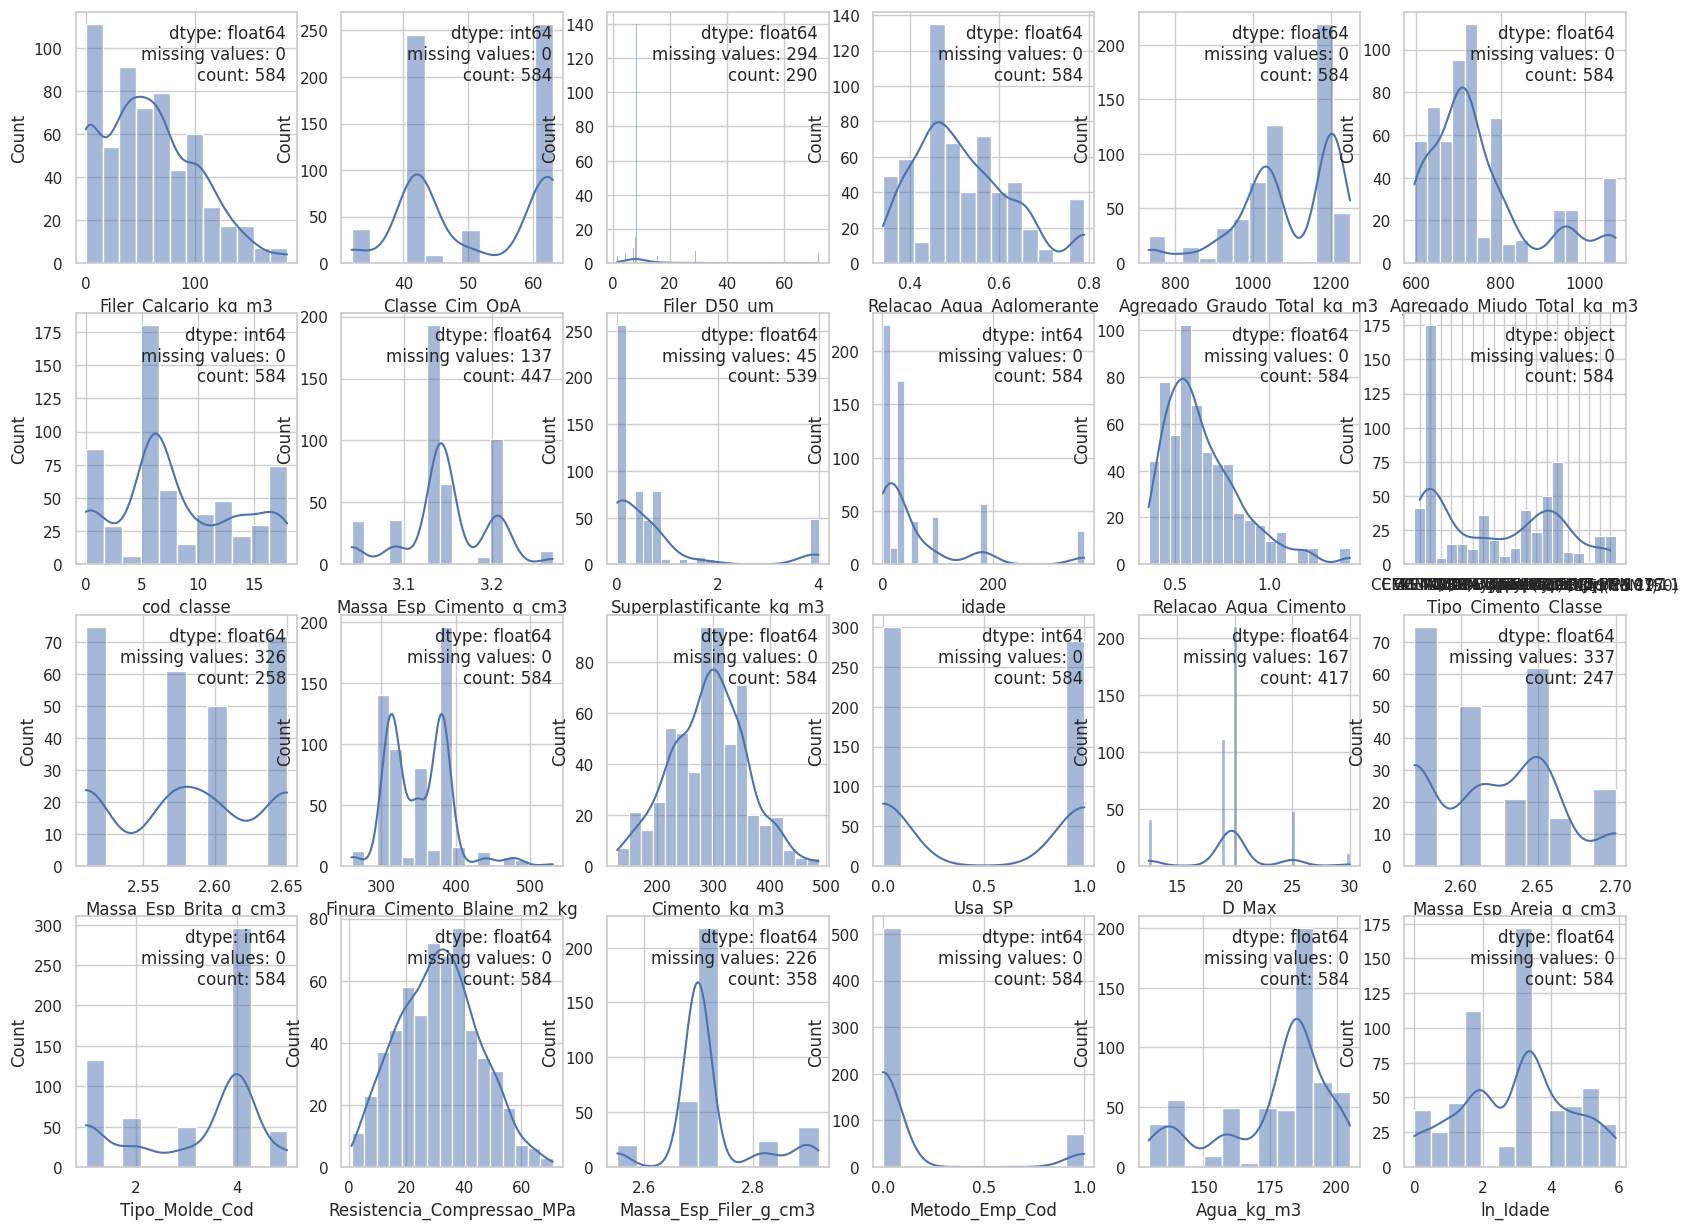

In [368]:
columns = set(df_resistencia.columns)
exclude = {'Autores/ano', 'ID_Mistura'}
columns -= exclude
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 15))
axes = axes.flatten()

for i, column in enumerate(columns):
    text = (f"dtype: {df_resistencia[column].dtype}\n"
            f"missing values: {df_resistencia[column].isnull().sum()}\n"
            f"count: {df_resistencia[column].count()}")
    axes[i].text(0.95, 0.95, text, transform=axes[i].transAxes,
                        verticalalignment='top', horizontalalignment='right')
    sns.histplot(df_resistencia[column], ax=axes[i], kde=True)

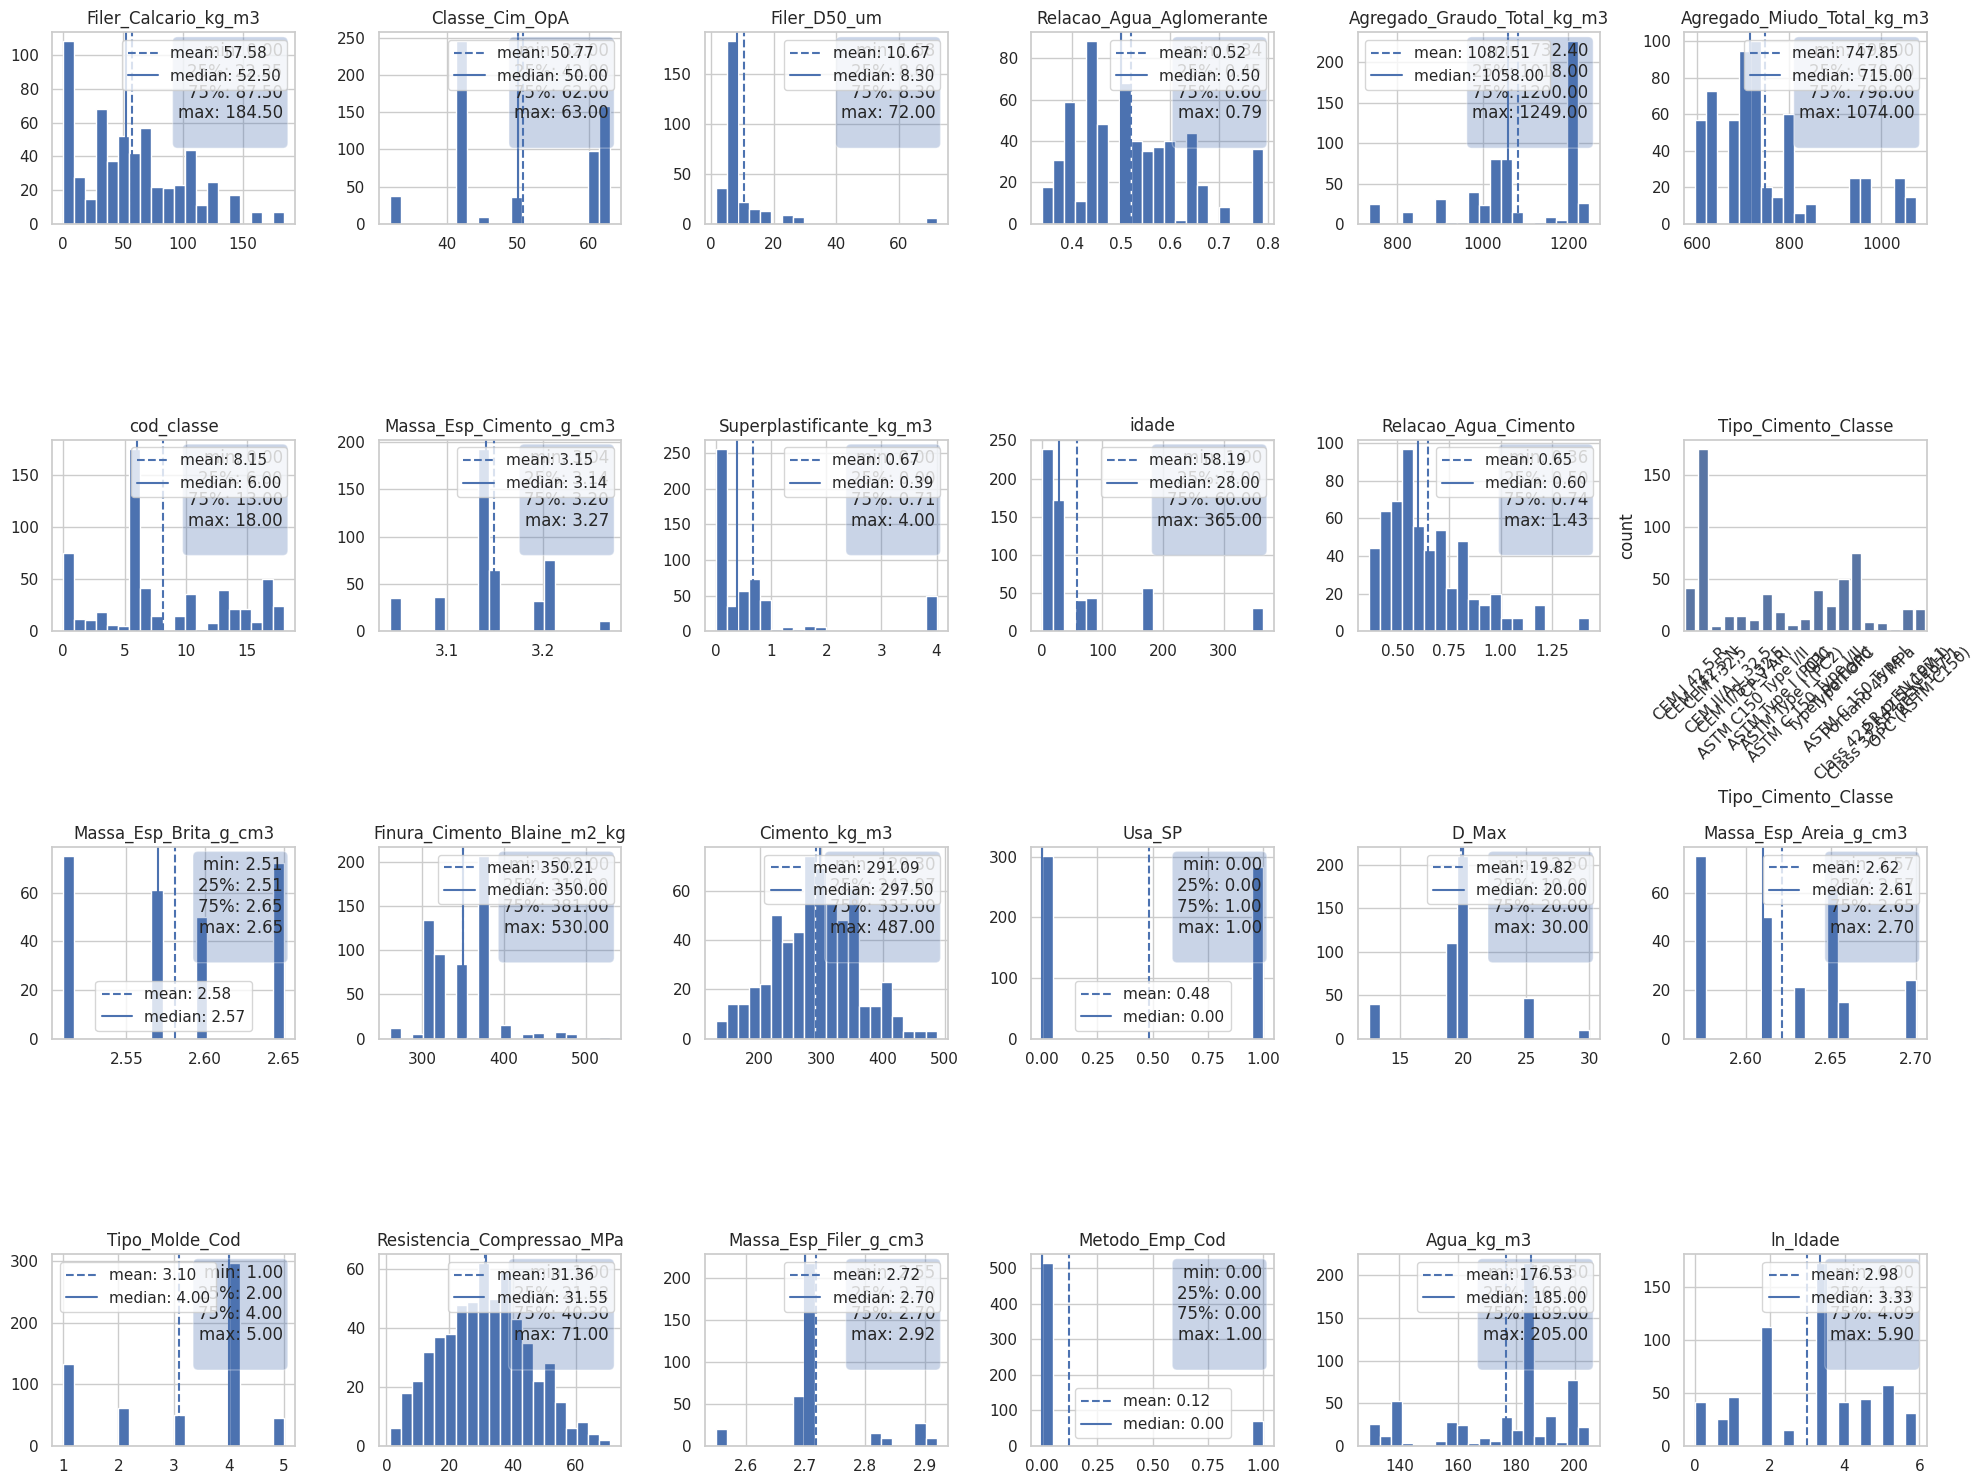

In [369]:
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 15))

axes = axes.flatten()

for i, column in enumerate(columns):
    ax = axes[i]
    data = df_resistencia[column]
    if data.dtype == 'object':
        ax.set_title(column)
        sns.countplot(x=data, ax=ax)
        ax.tick_params(axis='x', rotation=45)
        continue

    ax.set_title(column)
    ax.hist(data, bins=20)

    stats = data.describe()

    # Linhas de referência
    ax.axvline(stats['mean'], linestyle='--', label=f"mean: {stats['mean']:.2f}")
    ax.axvline(stats['50%'], linestyle='-', label=f"median: {stats['50%']:.2f}")

    # Texto com resumo
    text = (
        f"min: {stats['min']:.2f}\n"
        f"25%: {stats['25%']:.2f}\n"
        f"75%: {stats['75%']:.2f}\n"
        f"max: {stats['max']:.2f}\n"
    )

    ax.text(
        0.95, 0.95, text,
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle="round", alpha=0.3)
    )

    ax.legend()

plt.tight_layout()
plt.show()

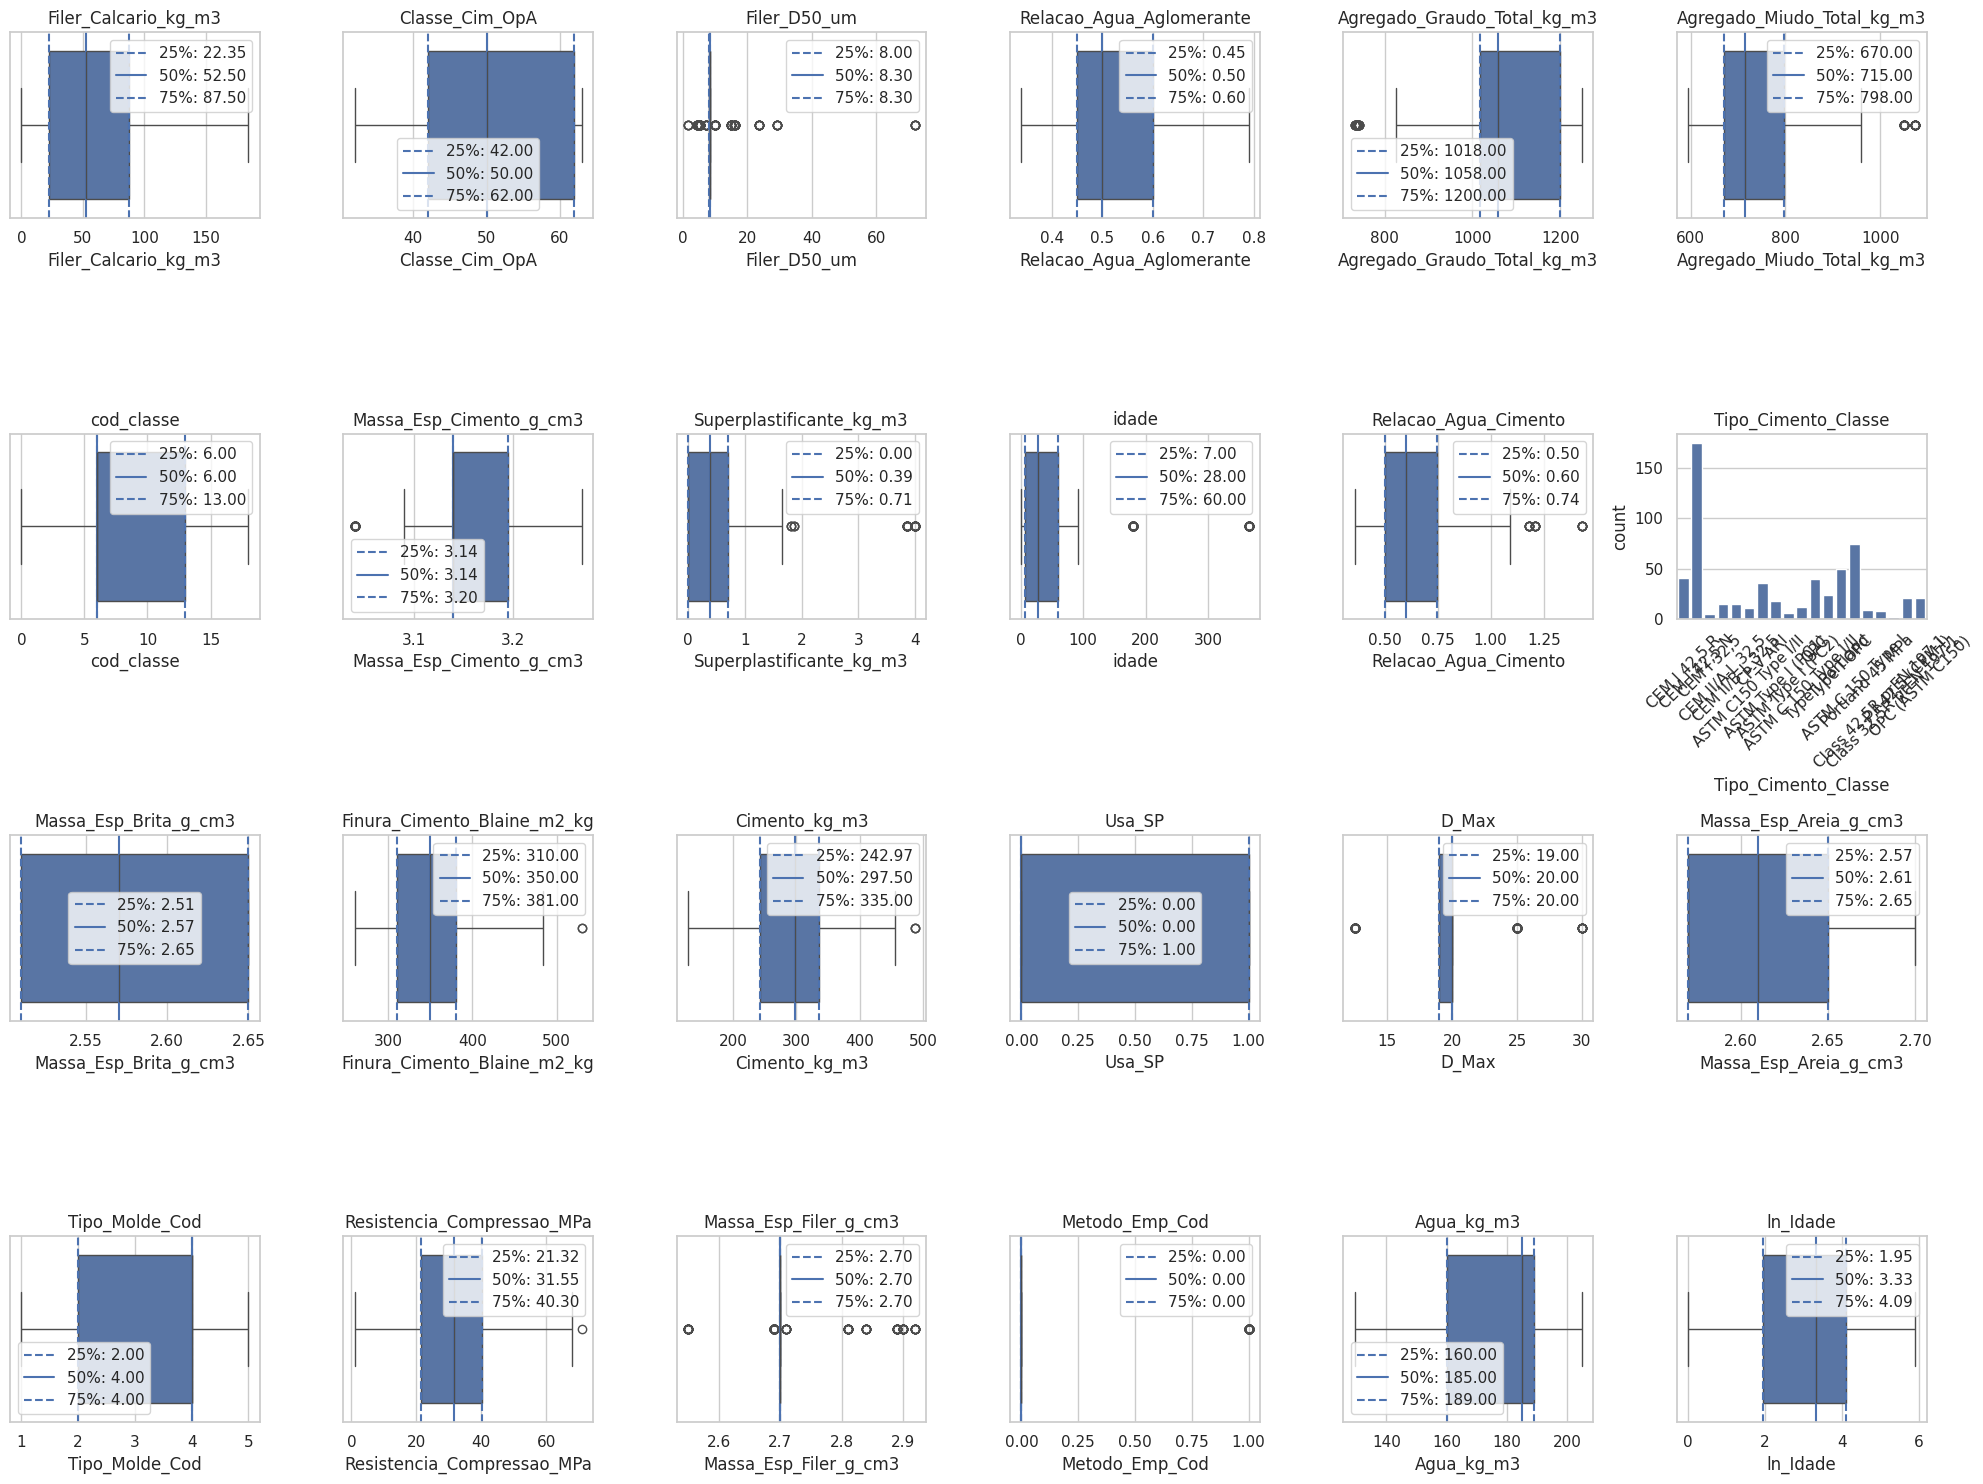

In [370]:
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 15))

axes = axes.flatten()

for i, column in enumerate(columns):
    ax = axes[i]
    data = df_resistencia[column]
    if data.dtype == 'object':
        ax.set_title(column)
        sns.countplot(x=data, ax=ax)
        ax.tick_params(axis='x', rotation=45)
        continue

    ax.set_title(column)
    sns.boxplot(x=data, ax=ax)

    stats = data.describe()

    # Linhas de referência
    ax.axvline(stats['25%'], linestyle='--', label=f"25%: {stats['25%']:.2f}")
    ax.axvline(stats['50%'], linestyle='-', label=f"50%: {stats['50%']:.2f}")
    ax.axvline(stats['75%'], linestyle='--', label=f"75%: {stats['75%']:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

In [371]:
# Removendo coluna 'idade' de forma efetiva
df_resistencia.drop(columns=['idade'], inplace=True)

In [372]:
df_resistencia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 15 to 598
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Autores/ano                  584 non-null    object 
 1   ID_Mistura                   584 non-null    object 
 2   Tipo_Cimento_Classe          584 non-null    object 
 3   Massa_Esp_Cimento_g_cm3      447 non-null    float64
 4   Finura_Cimento_Blaine_m2_kg  584 non-null    float64
 5   Massa_Esp_Filer_g_cm3        358 non-null    float64
 6   Massa_Esp_Areia_g_cm3        247 non-null    float64
 7   Massa_Esp_Brita_g_cm3        258 non-null    float64
 8   Cimento_kg_m3                584 non-null    float64
 9   Filer_Calcario_kg_m3         584 non-null    float64
 10  Agua_kg_m3                   584 non-null    float64
 11  Agregado_Miudo_Total_kg_m3   584 non-null    float64
 12  Agregado_Graudo_Total_kg_m3  584 non-null    float64
 13  Superplastificante_kg_m3

In [373]:
df_mix = (
    df_resistencia
    .groupby("ID_Mistura")
    .mean(numeric_only=True)
)

colunas_cluster_original = [
    'Finura_Cimento_Blaine_m2_kg',
    'Cimento_kg_m3',
    'Filer_Calcario_kg_m3',
    'Agua_kg_m3',
    'Agregado_Miudo_Total_kg_m3',
    'Agregado_Graudo_Total_kg_m3',
    'cod_classe'
]

X_cluster = df_mix[colunas_cluster_original].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

for k in [5, 8, 10, 12, 15, 20, 40, 50, 75, 100]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)

    print(
        f"k={k}",
        f"silhouette={sil:.3f}",
        f"min={np.bincount(labels).min()}",
        f"max={np.bincount(labels).max()}"
    )

k=5 silhouette=0.288 min=10 max=51
k=8 silhouette=0.324 min=7 max=35
k=10 silhouette=0.320 min=5 max=23
k=12 silhouette=0.306 min=4 max=23
k=15 silhouette=0.321 min=5 max=21
k=20 silhouette=0.320 min=4 max=18
k=40 silhouette=0.395 min=1 max=11
k=50 silhouette=0.409 min=1 max=11
k=75 silhouette=0.416 min=1 max=8
k=100 silhouette=0.360 min=1 max=3


In [374]:
best_kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=20
)

df_mix["familia_cod"] = best_kmeans.fit_predict(X_scaled)

cluster_map = df_mix["familia_cod"]

df_resistencia["familia_cod"] = (
    df_resistencia["ID_Mistura"]
    .map(cluster_map)
)

In [320]:
df_resistencia.groupby("ID_Mistura")["familia_cod"].nunique().describe()

,familia_cod
count,151.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [321]:
df_resistencia['familia_cod'].value_counts()


,count
familia_cod,
4,120
1,107
3,101
6,85
0,58
7,48
2,40
5,25


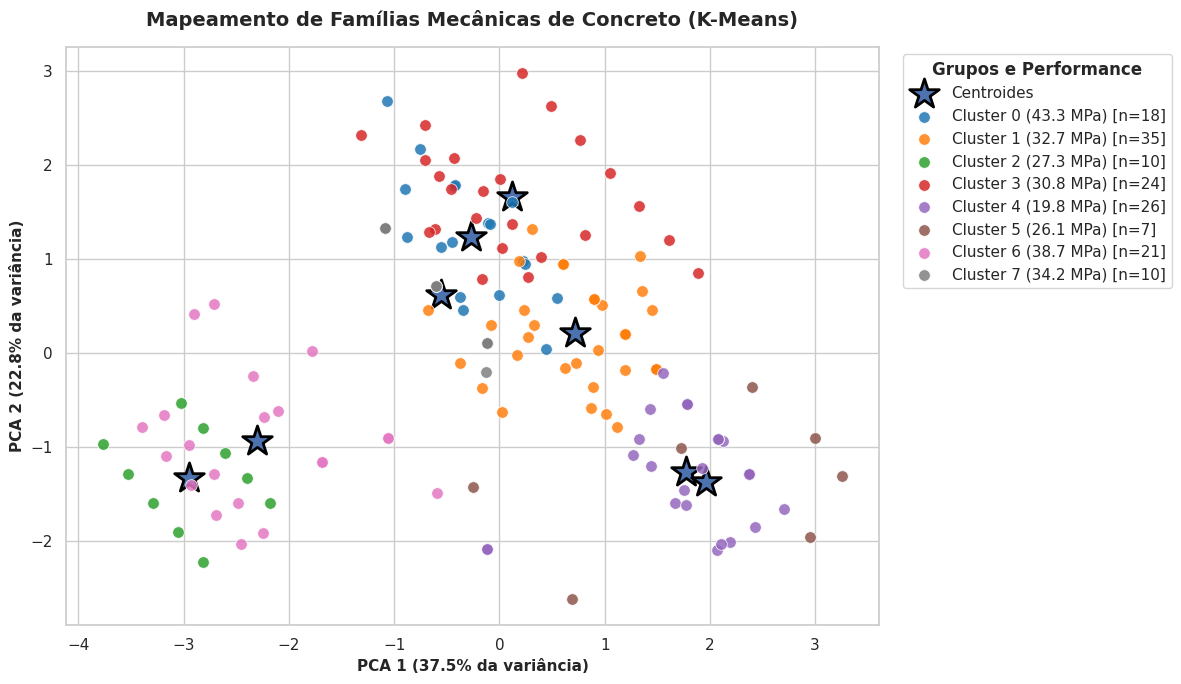

In [322]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot = df_mix.copy()
df_plot["PCA1"] = X_pca[:, 0]
df_plot["PCA2"] = X_pca[:, 1]

var_explicada = pca.explained_variance_ratio_ * 100

centroids = best_kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    marker='*',
    s=500,
    edgecolors='black',
    linewidths=2,
    label='Centroides'
)

clusters_validos = [c for c in sorted(df_plot["familia_cod"].unique()) if c != -1]
palette = sns.color_palette("tab10", n_colors=len(clusters_validos))

color_idx = 0
for cluster in sorted(df_plot["familia_cod"].unique()):
    subset = df_plot[df_plot["familia_cod"] == cluster]

    media_mpa = subset["Resistencia_Compressao_MPa"].mean()
    plt.scatter(
        subset["PCA1"], subset["PCA2"],
        color=palette[color_idx], alpha=0.85, edgecolors="w", s=70, linewidths=0.6,
        label=f"Cluster {cluster} ({media_mpa:.1f} MPa) [n={len(subset)}]"
    )
    color_idx += 1

plt.xlabel(f"PCA 1 ({var_explicada[0]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.ylabel(f"PCA 2 ({var_explicada[1]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.title("Mapeamento de Famílias Mecânicas de Concreto (K-Means)", fontsize=14, fontweight='bold', pad=15)

legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Grupos e Performance", frameon=True)
legend.get_title().set_fontweight('bold')

plt.tight_layout()
plt.show()

In [323]:
print(
    "Variância explicada:",
    pca.explained_variance_ratio_.sum()
)

Variância explicada: 0.6033805742083848


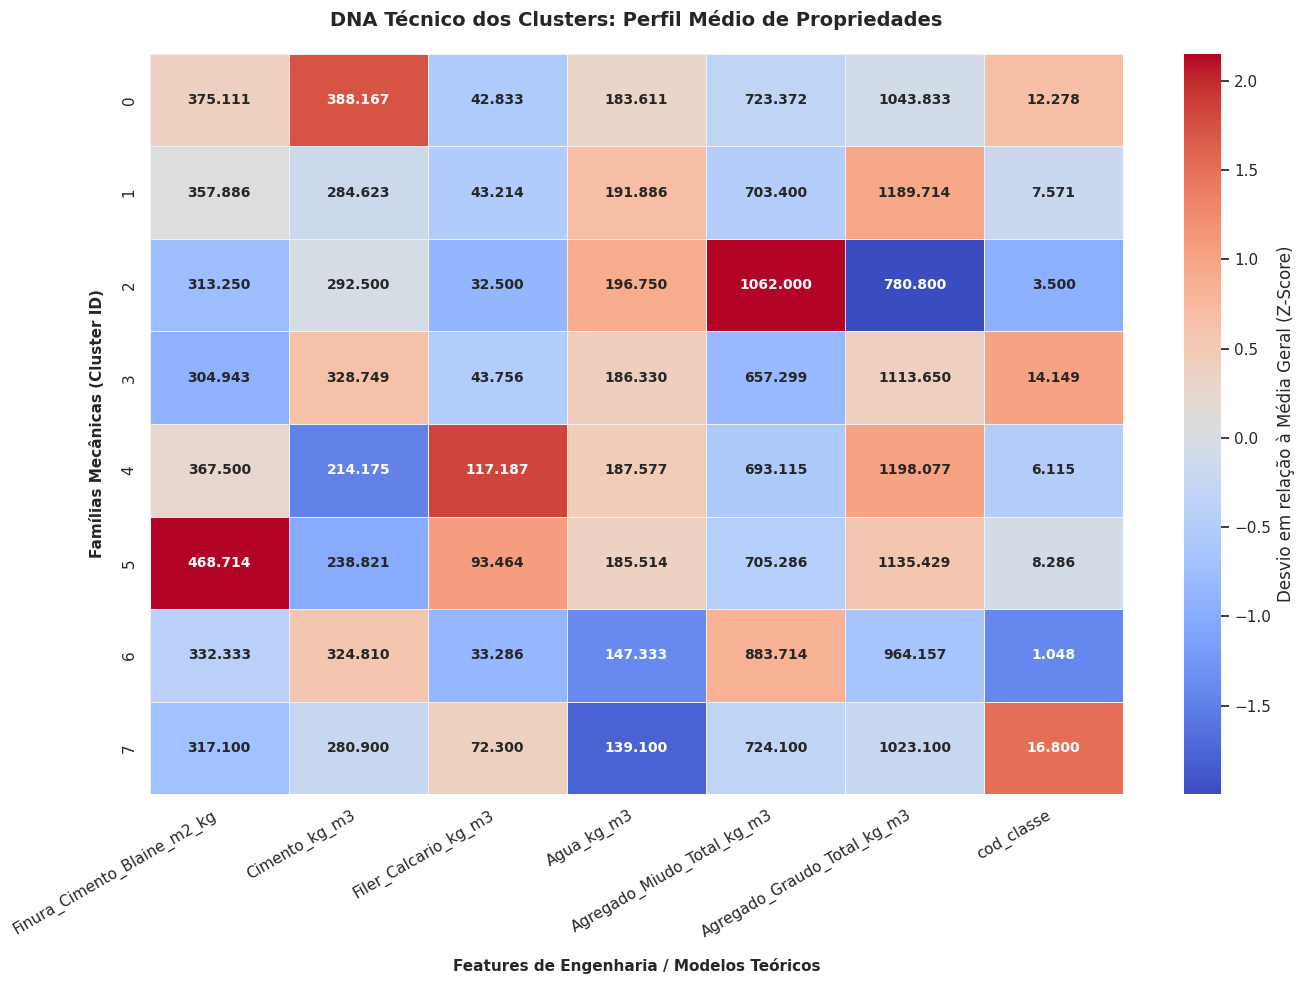

In [324]:
# 1. Calculando a média real por cluster
cluster_profile_raw = (
    df_mix

    .groupby("familia_cod")[colunas_cluster_original]
    .mean()
)

# Isso diz quantos desvios padrões o cluster está acima (vermelho) ou abaixo (azul) da média geral
cluster_profile_scaled = (cluster_profile_raw - cluster_profile_raw.mean()) / cluster_profile_raw.std()

# 3. Configuração da figura (mais alta para caber os 18 clusters sem espremer)
plt.figure(figsize=(14, 10))

# 4. Construindo o Heatmap Inteligente
sns.heatmap(
    cluster_profile_scaled,
    annot=cluster_profile_raw.values, # <-- EXIBE OS VALORES REAIS
    fmt=".3f",                        # <-- Formata com 3 casas decimais
    cmap="coolwarm",                  # <-- Azul (Abaixo da média) | Vermelho (Acima da média)
    linewidths=0.7,                   # <-- Linha fina para separar os blocos
    linecolor="#F0F0F0",
    cbar_kws={'label': 'Desvio em relação à Média Geral (Z-Score)'},
    annot_kws={"size": 10, "weight": "semibold"} # Texto interno legível
)

# 5. Ajustes estéticos e labels
plt.title("DNA Técnico dos Clusters: Perfil Médio de Propriedades", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Features de Engenharia / Modelos Teóricos", fontsize=11, fontweight='bold', labelpad=12)
plt.ylabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=12)
plt.xticks(rotation=30, ha="right") # Rotaciona os nomes das colunas para não encavalar
plt.tight_layout()
plt.show()

/tmp/ipykernel_19118/3085485636.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


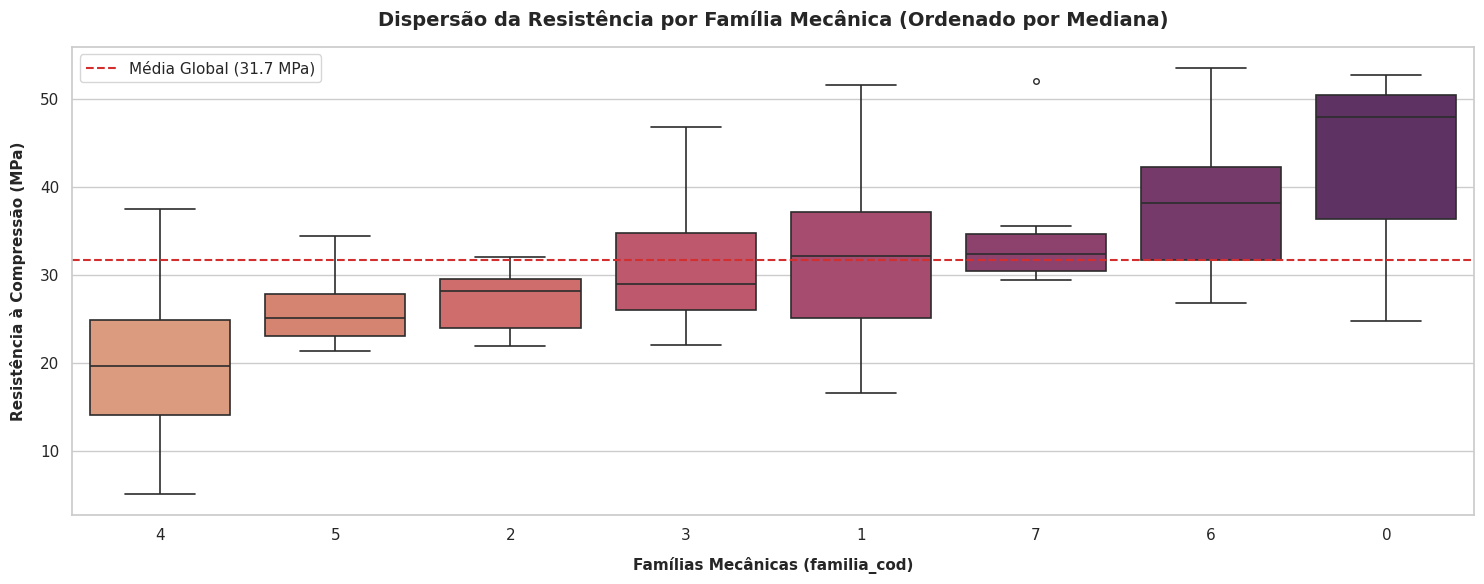

In [325]:
ordem_clusters = (
    df_mix
    .groupby("familia_cod")["Resistencia_Compressao_MPa"]
    .median()
    .sort_values()
    .index
)

# 2. Configuração estética do ambiente
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6)) # Aumentamos a largura para acomodar os 18 grupos sem espremer

# 3. Plot do Boxplot ordenado com uma paleta de degradê (flare ou viridis)
sns.boxplot(
    data=df_mix,
    x="familia_cod",
    y="Resistencia_Compressao_MPa",
    order=ordem_clusters,     # <-- Aplica a ordenação em escada
    palette="flare",          # <-- Cria um degradê suave acompanhando a subida
    linewidth=1.2,
    fliersize=4               # Tamanho dos outliers internos de cada cluster
)

# 4. Adiciona uma linha horizontal com a média global da base de dados
media_global = df_mix["Resistencia_Compressao_MPa"].mean()
plt.axhline(
    media_global,
    color="#D32F2F",
    linestyle="--",
    linewidth=1.5,
    label=f"Média Global ({media_global:.1f} MPa)"
)

# 5. Ajustes finais de polimento
plt.title("Dispersão da Resistência por Família Mecânica (Ordenado por Mediana)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Famílias Mecânicas (familia_cod)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Resistência à Compressão (MPa)", fontsize=11, fontweight='bold', labelpad=10)

# Como a figura está larga, rotação 0 ou 30 já é suficiente para leitura
plt.xticks(rotation=0)

plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [326]:
# Verificando se os clusters fazem sentido
analise_resistencia = df_resistencia.groupby('familia_cod')['Resistencia_Compressao_MPa'].agg(['mean', 'std', 'count', 'min', 'max'])
print(analise_resistencia)

                  mean        std  count    min    max
familia_cod                                           
0            43.842586  12.236455     58  18.30  71.00
1            33.208224  13.651438    107   6.50  63.00
2            27.145000   8.237782     40  11.00  42.30
3            30.826238  11.631605    101   3.72  54.42
4            20.095417  11.452485    120   1.00  51.00
5            25.584000   7.530531     25  11.00  41.70
6            39.571765  12.359462     85  14.00  67.00
7            33.454167  10.285436     48  11.90  53.70


In [327]:
df_resistencia["Usa_SP"] = df_resistencia["Usa_SP"].astype(bool)

In [328]:
df_resistencia.Usa_SP.dtype

dtype('bool')

In [329]:
# ==========================================
# CONSTANTES
# ==========================================
# 1. Definimos a lista dos materiais que precisam da correção de densidade
colunas_densidade = [
    'Massa_Esp_Cimento_g_cm3',
    'Massa_Esp_Areia_g_cm3',
    'Massa_Esp_Brita_g_cm3',
    'Massa_Esp_Filer_g_cm3',
    'Superplastificante_kg_m3',
    'D_Max', 'Filer_D50_um'
]

for col in colunas_densidade:
    # Passo A: Imputação com Média do próprio Cluster
    df_resistencia[col] = df_resistencia.groupby('familia_cod')[col].transform(
        lambda x: x.fillna(x.mean())
    )

    # Passo B: A Trava de Segurança (Fallback para a Média Global)
    media_global = df_resistencia[col].mean()
    df_resistencia[col] = df_resistencia[col].fillna(media_global)

    # Verificação em tempo real
    nulos_restantes = df_resistencia[col].isna().sum()
    print(f"✅ {col}: {nulos_restantes} nulos restantes.")

# Tratamento especifico para Superplastificante_kg_m3 que depende diretamente de Usa_SP
df_resistencia.loc[~df_resistencia['Usa_SP'], 'Superplastificante_kg_m3'] = 0.0

# Quando não há filler seu tamanho deve ser 0, não faz sentido ter um D50.
df_resistencia.loc[df_resistencia['Filer_Calcario_kg_m3'] == 0, 'f'] = 0.0

df_resistencia['Massa_Esp_Cimento_kg_m3'] = df_resistencia['Massa_Esp_Cimento_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_resistencia['Massa_Esp_Areia_kg_m3'] =  df_resistencia['Massa_Esp_Areia_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_resistencia['Massa_Esp_Brita_kg_m3'] = df_resistencia['Massa_Esp_Brita_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_resistencia['Massa_Esp_Filer_kg_m3'] = df_resistencia['Massa_Esp_Filer_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_resistencia.drop(columns=['Massa_Esp_Cimento_g_cm3', 'Massa_Esp_Areia_g_cm3', 'Massa_Esp_Brita_g_cm3', 'Massa_Esp_Filer_g_cm3'], inplace=True)

# 2. Atualizando as variáveis que vão alimentar a sua matriz de volumes absolutos
DENSIDADE_CIMENTO = df_resistencia['Massa_Esp_Cimento_kg_m3']  # Usando a coluna já convertida
DENSIDADE_AREIA = df_resistencia['Massa_Esp_Areia_kg_m3']  # Usando a coluna já convertida
DENSIDADE_BRITA = df_resistencia['Massa_Esp_Brita_kg_m3']  # Usando a coluna já convertida
DENSIDADE_FILER = df_resistencia['Massa_Esp_Filer_kg_m3']  # Usando a coluna já convertida
DENSIDADE_AGUA = 1000
DENSIDADE_SP = 1100

✅ Massa_Esp_Cimento_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Areia_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Brita_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Filer_g_cm3: 0 nulos restantes.
✅ Superplastificante_kg_m3: 0 nulos restantes.
✅ D_Max: 0 nulos restantes.
✅ Filer_D50_um: 0 nulos restantes.


In [330]:
# Dicionário de Mapeamento do Coeficiente 's' do fib Model Code
# Baseado na norma europeia (EN 197-1), ASTM (C150) e brasileira
mapa_coeficiente_s = {
    # s = 0.20 (Rápido / Alta Resistência Inicial)
    'CP-V ARI': 0.20,
    'CEM I 42,5 R': 0.20,
    'Class 42.5R prEN 197-1': 0.20,
    'Portland 45 MPa': 0.20,

    # s = 0.25 (Normal / OPC Tradicional)
    'CEM I 42,5 N': 0.25,
    'ASTM C150 Type I/II': 0.25,
    'ASTM Type I (PC1)': 0.25,
    'ASTM Type I (PC2)': 0.25,
    'ASTM C 150 Type I/II': 0.25,
    'ASTM C 150 Type I': 0.25,
    'OPC': 0.25,
    'Type I Portland': 0.25,
    'Type I OPC': 0.25,
    'OPC (ASTM C150)': 0.25,
    'P,I 42,5 (CEM I)': 0.25,

    # s = 0.38 (Lento / Baixa classe ou com adições como Fíler Calcário - L)
    'CEM I 32,5': 0.38,
    'CEM II/A-L 32,5': 0.38,
    'CEM II/B-L 32,5': 0.38
}

In [331]:
# ==========================================
# FEATURE ENGINEERING - CONCRETE COMPRESSIVE STRENGTH
# ==========================================

EPS = np.finfo(float).eps

# ==========================================
# 1. CÁLCULO DE VOLUMES ABSOLUTOS
# ==========================================
print("\n" + "=" * 50)
print("1. VOLUMES ABSOLUTOS")
print("=" * 50)

df_resistencia['vol_cimento'] = pd.to_numeric(df_resistencia['Cimento_kg_m3'], errors='coerce') / df_resistencia['Massa_Esp_Cimento_kg_m3']
df_resistencia['vol_agua'] = pd.to_numeric(df_resistencia['Agua_kg_m3'], errors='coerce') / DENSIDADE_AGUA
df_resistencia['vol_filer'] = pd.to_numeric(df_resistencia['Filer_Calcario_kg_m3'], errors='coerce') / df_resistencia['Massa_Esp_Filer_kg_m3']
df_resistencia['vol_areia'] = pd.to_numeric(df_resistencia['Agregado_Miudo_Total_kg_m3'], errors='coerce') / df_resistencia['Massa_Esp_Areia_kg_m3']
df_resistencia['vol_brita'] = pd.to_numeric(df_resistencia['Agregado_Graudo_Total_kg_m3'], errors='coerce') / df_resistencia['Massa_Esp_Brita_kg_m3']
df_resistencia['vol_sp'] = pd.to_numeric(df_resistencia['Superplastificante_kg_m3'], errors='coerce') / DENSIDADE_SP

# ==========================================
# 2. FECHAMENTO VOLUMÉTRICO E POROSIDADE
# ==========================================
print("\n" + "=" * 50)
print("2. FECHAMENTO VOLUMÉTRICO E POROSIDADE")
print("=" * 50)

# Volume total de materiais
df_resistencia['volume_materiais'] = (
    df_resistencia['vol_cimento'] +
    df_resistencia['vol_agua'] +
    df_resistencia['vol_filer'] +
    df_resistencia['vol_areia'] +
    df_resistencia['vol_brita'] +
    df_resistencia['vol_sp']
)

# Ar aprisionado
df_resistencia['vol_ar_aprisionado'] = (
    1.0 - df_resistencia['volume_materiais']
).clip(lower=0)

# Porosidade e índice de vazios
df_resistencia['porosidade_volumetrica_inicial'] = (
    df_resistencia['vol_agua'] + df_resistencia['vol_ar_aprisionado']
)

df_resistencia['vol_solidos_totais'] = (
    df_resistencia['vol_cimento'] +
    df_resistencia['vol_filer'] +
    df_resistencia['vol_areia'] +
    df_resistencia['vol_brita']
)

df_resistencia['indice_vazios'] = (
    df_resistencia['porosidade_volumetrica_inicial'] /
    df_resistencia['vol_solidos_totais'].clip(lower=EPS)
)

# ==========================================
# 3. ESTRUTURA DO CONCRETO
# ==========================================
print("\n" + "=" * 50)
print("3. ESTRUTURA DO CONCRETO")
print("=" * 50)

# Volumes de agregados e pasta
df_resistencia['vol_agregados'] = (
    df_resistencia['vol_areia'] + df_resistencia['vol_brita']
)

df_resistencia['vol_pasta'] = (
    df_resistencia['vol_cimento'] +
    df_resistencia['vol_agua'] +
    df_resistencia['vol_filer']
)

df_resistencia['vol_po_total'] = (
    df_resistencia['vol_cimento'] + df_resistencia['vol_filer']
)

# Proporções
df_resistencia['pasta_agregado'] = (
    df_resistencia['vol_pasta'] /
    df_resistencia['vol_agregados'].clip(lower=EPS)
)

df_resistencia['fracao_agregados'] = df_resistencia['vol_agregados']  # Já está em base 1.0

# ==========================================
# 4. RELAÇÕES DE MASSA E FINOS
# ==========================================
print("\n" + "=" * 50)
print("4. RELAÇÕES DE MASSA E FINOS")
print("=" * 50)

# Aglomerante total
df_resistencia['aglomerante_total'] = (
    df_resistencia['Cimento_kg_m3'] + df_resistencia['Filer_Calcario_kg_m3']
)

# Relação água/cimento (inversa)
df_resistencia['inv_a_c'] = (
    1.0 / df_resistencia['Relacao_Agua_Cimento'].clip(lower=EPS)
)

# Fator água/pó (volumétrico)
df_resistencia['fator_agua_po'] = (
    df_resistencia['vol_agua'] /
    df_resistencia['vol_po_total'].clip(lower=EPS)
)

# Proporção de finos
df_resistencia['finos_total'] = (
    df_resistencia['Filer_Calcario_kg_m3'] /
    df_resistencia['Cimento_kg_m3'].clip(lower=EPS)
)

df_resistencia['taxa_filer_inerte'] = (
    df_resistencia['Filer_Calcario_kg_m3'] /
    df_resistencia['aglomerante_total'].clip(lower=EPS)
)

# ==========================================
# 5. SUPERPLASTIFICANTE
# ==========================================
print("\n" + "=" * 50)
print("5. SUPERPLASTIFICANTE")
print("=" * 50)

df_resistencia['taxa_sp_cimento'] = (
    df_resistencia['Superplastificante_kg_m3'] /
    df_resistencia['Cimento_kg_m3'].clip(lower=EPS)
)

df_resistencia['taxa_sp_aglomerante'] = (
    df_resistencia['Superplastificante_kg_m3'] /
    df_resistencia['aglomerante_total'].clip(lower=EPS)
)

# ==========================================
# 6. GRANULOMETRIA
# ==========================================
print("\n" + "=" * 50)
print("6. GRANULOMETRIA")
print("=" * 50)

df_resistencia["range_granulometrico"] = 0.0

mask = df_resistencia["Filer_Calcario_kg_m3"] > 0

df_resistencia.loc[mask, "range_granulometrico"] = (
    df_resistencia.loc[mask, "D_Max"] * 1000
    / df_resistencia.loc[mask, "Filer_D50_um"]
)

# ==========================================
# 7. FEATURES TEMPORAIS BÁSICAS
# ==========================================
print("\n" + "=" * 50)
print("7. FEATURES TEMPORAIS BÁSICAS")
print("=" * 50)

# Idade em dias
idade_dias = np.exp(df_resistencia['ln_Idade'])

# Interação idade × a/c
df_resistencia['idade_fator_agua'] = (
    df_resistencia['ln_Idade'] /
    df_resistencia['Relacao_Agua_Cimento'].clip(lower=EPS)
)

# ==========================================
# 8. MODELO DE FÉRET
# ==========================================
print("\n" + "=" * 50)
print("8. MODELO DE FÉRET")
print("=" * 50)

# Parâmetro de Féret básico
df_resistencia['parametro_feret'] = (
    df_resistencia['vol_cimento'] /
    (
        df_resistencia['vol_cimento'] +
        df_resistencia['vol_agua'] +
        df_resistencia['vol_ar_aprisionado']
    ).clip(lower=EPS)
) ** 2

# Interação com idade
df_resistencia['idade_feret'] = (
    df_resistencia['ln_Idade'] * df_resistencia['parametro_feret']
)

# Féret corrigido por condições de contorno (CBC)
vazios_agregados_estimado = df_resistencia['vol_agregados'] * 0.30

df_resistencia['saturacao_pasta'] = (
    df_resistencia['vol_pasta'] / vazios_agregados_estimado.clip(lower=EPS)
)

saturacao_pasta_mask = df_resistencia['saturacao_pasta'].clip(upper=1.0)

df_resistencia['qualidade_adensamento'] = np.exp(-df_resistencia['vol_ar_aprisionado'] * 50)

df_resistencia['fator_resistencia_rocha'] = (
        (df_resistencia['Massa_Esp_Brita_kg_m3'] - 2400).clip(lower=0) / (3000 - 2400)
    ).clip(upper=1.0)

df_resistencia['indice_conformidade_feret'] = (
    saturacao_pasta_mask *
    df_resistencia['qualidade_adensamento'] *
    df_resistencia['fator_resistencia_rocha']
)

df_resistencia['feret_corrigido_contorno'] = (
    df_resistencia['parametro_feret'] * df_resistencia['indice_conformidade_feret']
)

# O denominador do Féret Modificado é o volume total da pasta real
vol_pasta_real = (
    df_resistencia['vol_cimento'] +
    df_resistencia['vol_filer'] +
    df_resistencia['vol_agua'] +
    df_resistencia['vol_ar_aprisionado']
).clip(lower=EPS)

# Criamos uma lista de fatores 'k' para testar (0.0 seria o Féret clássico ignorando o fíler)
fatores_k = [0.05, 0.10, 0.15, 0.20]

for k in fatores_k:
    nome_coluna = f'parametro_feret_filer_k{int(k*100)}'

    # Numerador: Volume Equivalente (Cimento + k * Fíler)
    vol_equivalente = df_resistencia['vol_cimento'] + (k * df_resistencia['vol_filer'])

    # A equação de Féret Modificada
    df_resistencia[nome_coluna] = (vol_equivalente / vol_pasta_real) ** 2

    # Criamos também a interação com o tempo (Cinética) para cada versão
    df_resistencia[f'idade_{nome_coluna}'] = df_resistencia['ln_Idade'] * df_resistencia[nome_coluna]

# ==========================================
# 9. CINÉTICA DE HIDRATAÇÃO
# ==========================================
print("\n" + "=" * 50)
print("9. CINÉTICA DE HIDRATAÇÃO")
print("=" * 50)

df_resistencia['potencial_reativo_tempo'] = (
    df_resistencia['ln_Idade'] * (df_resistencia['Finura_Cimento_Blaine_m2_kg'] / 1000)
)

df_resistencia['cinetica_real'] = (
    df_resistencia['potencial_reativo_tempo'] /
    df_resistencia['Relacao_Agua_Cimento'].clip(lower=EPS)
)

# ==========================================
# 10. MODELO DE POWERS
# ==========================================
print("\n" + "=" * 50)
print("10. MODELO DE POWERS")
print("=" * 50)

# Baseado em massa
df_resistencia['pow_gel_space_mass'] = 0.68 / (df_resistencia['Relacao_Agua_Cimento'] + 0.32)

# Baseado em volume (com ar aprisionado)
df_resistencia['pow_gel_space_vol'] = (
    (2.06 * df_resistencia['vol_cimento']) /
    (df_resistencia['vol_cimento'] + df_resistencia['vol_agua'] + df_resistencia['vol_ar_aprisionado'])
)

# Lei cúbica de Powers
df_resistencia['pow_cubo_vol'] = df_resistencia['pow_gel_space_vol'] ** 3

# Interação temporal
df_resistencia['pow_interacao_tempo'] = (
    df_resistencia['pow_cubo_vol'] * df_resistencia['ln_Idade']
)

# Razão Powers/Féret
df_resistencia['razao_powers_feret'] = (
    df_resistencia['pow_gel_space_vol'] / df_resistencia['parametro_feret']
)

# ==========================================
# 11. MODELO DE RYSHKEWITCH
# ==========================================
print("\n" + "=" * 50)
print("11. MODELO DE RYSHKEWITCH")
print("=" * 50)

B_empirico = 5.0

# Porosidade real (considerando ar)
porosidade_real = (
    (df_resistencia['vol_agua'] + df_resistencia['vol_ar_aprisionado']) /
    df_resistencia['volume_materiais']
)

# Ryshkewitch inicial
df_resistencia['ryshkewitch_inicial'] = np.exp(-B_empirico * df_resistencia['porosidade_volumetrica_inicial'])

# Ryshkewitch real
df_resistencia['ryshkewitch_real'] = np.exp(-B_empirico * porosidade_real)

# Ryshkewitch cinético
porosidade_atual_estimada = df_resistencia['porosidade_volumetrica_inicial'] / (df_resistencia['ln_Idade'] + 1)
df_resistencia['ryshkewitch_cinetico'] = np.exp(-B_empirico * porosidade_atual_estimada)

# Linearização logarítmica
df_resistencia['ryshkewitch_linearizado'] = -df_resistencia['porosidade_volumetrica_inicial']

# ==========================================
# 12. MODELO DE HASSELMANN
# ==========================================
print("\n" + "=" * 50)
print("12. MODELO DE HASSELMANN")
print("=" * 50)

K_HASSELMAN = 3.0

# Hasselmann inicial
df_resistencia['hasselman_fator_inicial'] = 1 - (K_HASSELMAN * df_resistencia['porosidade_volumetrica_inicial'])

# Hasselmann real
df_resistencia['hasselman_fator_real'] = 1 - (K_HASSELMAN * porosidade_real)

# Hasselmann cinético
porosidade_cinetica = df_resistencia['porosidade_volumetrica_inicial'] / (df_resistencia['ln_Idade'] + 1)
df_resistencia['hasselman_cinetico'] = 1 - (K_HASSELMAN * porosidade_cinetica)

# Resiliência
df_resistencia['hasselman_resiliencia_agua'] = (
    df_resistencia['hasselman_fator_real'] / df_resistencia['vol_agua']
)

# ==========================================
# 13. MODELO DE SCHILLER
# ==========================================
print("\n" + "=" * 50)
print("13. MODELO DE SCHILLER")
print("=" * 50)

P_CR = 0.50

# Schiller inicial
p_seguro_inicial = df_resistencia['porosidade_volumetrica_inicial'].clip(lower=0.001, upper=P_CR - 0.001)
df_resistencia['schiller_inicial'] = np.log(P_CR / p_seguro_inicial)

# Schiller real
p_seguro_real = porosidade_real.clip(lower=0.001, upper=P_CR - 0.001)
df_resistencia['schiller_real'] = np.log(P_CR / p_seguro_real)

# Schiller cinético
porosidade_cinetica_schiller = porosidade_real / (df_resistencia['ln_Idade'] + 1)
p_seguro_cinetico = porosidade_cinetica_schiller.clip(lower=0.001, upper=P_CR - 0.001)
df_resistencia['schiller_cinetico'] = np.log(P_CR / p_seguro_cinetico)

# Margem de colapso
df_resistencia['margem_colapso_schiller'] = P_CR - porosidade_real

# ==========================================
# 14. MODELO ACI (AMERICANO)
# ==========================================
print("\n" + "=" * 50)
print("14. MODELO ACI")
print("=" * 50)

t_dias = np.exp(df_resistencia['ln_Idade'])

# Fator temporal ACI 209R
df_resistencia['aci_209_fator_tempo'] = t_dias / (4.0 + 0.85 * t_dias)

# Estimativa base ACI 211 (28 dias)
df_resistencia['aci_211_base_28d'] = 96.0 / (4.0 ** df_resistencia['Relacao_Agua_Cimento'])

# Desvio
df_resistencia['aci_desvio_cimento'] = (
    df_resistencia['vol_cimento'] / (df_resistencia['aci_211_base_28d'] * df_resistencia['aci_209_fator_tempo'])
)

# ==========================================
# 15. MODELO FIB/ EUROCODE
# ==========================================
print("\n" + "=" * 50)
print("15. MODELO FIB/EUROCODE")
print("=" * 50)

# Coeficiente s
df_resistencia['s_fib'] = df_resistencia['Tipo_Cimento_Classe'].map(mapa_coeficiente_s)
df_resistencia['s_fib'] = df_resistencia.groupby('familia_cod')['s_fib'].transform(
    lambda x: x.fillna(x.mean())
)

# Fator temporal fib
t_dias_clip = np.exp(df_resistencia['ln_Idade']).clip(lower=1.0)
raiz_tempo = np.sqrt(28.0 / t_dias_clip)
df_resistencia['fib_fator_tempo'] = np.exp(df_resistencia['s_fib'] * (1 - raiz_tempo))

# Núcleo de Bolomey
df_resistencia['bolomey_nucleo_linear'] = (df_resistencia['inv_a_c'] - 0.5).clip(lower=0)

# Estimativa completa fib
df_resistencia['fib_estimativa_base'] = (
    df_resistencia['bolomey_nucleo_linear'] * df_resistencia['fib_fator_tempo']
)

# ==========================================
# 16. INTERAÇÕES ADICIONAIS
# ==========================================
print("\n" + "=" * 50)
print("16. INTERAÇÕES ADICIONAIS")
print("=" * 50)

df_resistencia['pasta_agregado_fino'] = (
    df_resistencia['vol_pasta'] / df_resistencia['vol_areia'].clip(lower=EPS)
)

df_resistencia['densidade_matriz'] = (
    df_resistencia['vol_po_total'] /
    (df_resistencia['vol_po_total'] + df_resistencia['vol_agua']).clip(lower=EPS)
)

# ==========================================
# RESUMO FINAL
# ==========================================
print("\n" + "=" * 50)
print("FEATURE ENGINEERING CONCLUÍDO")
print("=" * 50)
print(f"Total de features criadas: {len(df_resistencia.columns)}")
print(f"Total de amostras: {len(df_resistencia)}")


1. VOLUMES ABSOLUTOS

2. FECHAMENTO VOLUMÉTRICO E POROSIDADE

3. ESTRUTURA DO CONCRETO

4. RELAÇÕES DE MASSA E FINOS

5. SUPERPLASTIFICANTE

6. GRANULOMETRIA

7. FEATURES TEMPORAIS BÁSICAS

8. MODELO DE FÉRET

9. CINÉTICA DE HIDRATAÇÃO

10. MODELO DE POWERS

11. MODELO DE RYSHKEWITCH

12. MODELO DE HASSELMANN

13. MODELO DE SCHILLER

14. MODELO ACI

15. MODELO FIB/EUROCODE

16. INTERAÇÕES ADICIONAIS

FEATURE ENGINEERING CONCLUÍDO
Total de features criadas: 95
Total de amostras: 584


In [332]:
df_resistencia.columns

Index(['Autores/ano', 'ID_Mistura', 'Tipo_Cimento_Classe',
       'Finura_Cimento_Blaine_m2_kg', 'Cimento_kg_m3', 'Filer_Calcario_kg_m3',
       'Agua_kg_m3', 'Agregado_Miudo_Total_kg_m3',
       'Agregado_Graudo_Total_kg_m3', 'Superplastificante_kg_m3',
       'Relacao_Agua_Cimento', 'ln_Idade', 'Tipo_Molde_Cod', 'Metodo_Emp_Cod',
       'Usa_SP', 'Classe_Cim_OpA', 'Relacao_Agua_Aglomerante', 'Filer_D50_um',
       'D_Max', 'Resistencia_Compressao_MPa', 'cod_classe', 'familia_cod', 'f',
       'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Areia_kg_m3',
       'Massa_Esp_Brita_kg_m3', 'Massa_Esp_Filer_kg_m3', 'vol_cimento',
       'vol_agua', 'vol_filer', 'vol_areia', 'vol_brita', 'vol_sp',
       'volume_materiais', 'vol_ar_aprisionado',
       'porosidade_volumetrica_inicial', 'vol_solidos_totais', 'indice_vazios',
       'vol_agregados', 'vol_pasta', 'vol_po_total', 'pasta_agregado',
       'fracao_agregados', 'aglomerante_total', 'inv_a_c', 'fator_agua_po',
       'finos_total', 'taxa_file

In [333]:
exclude_columns = {'Autores/ano', 'ID_Mistura', 'Tipo_Cimento_Classe'}

In [334]:
df_mix = (
    df_resistencia
    .groupby("ID_Mistura")
    .mean(numeric_only=True)
)

# 1. Definindo as colunas do "DNA da Resistência"
colunas_cluster_derivadas = [
    "pow_gel_space_vol",
    "feret_corrigido_contorno",
    "indice_vazios",
    "densidade_matriz",
    "qualidade_adensamento",
    "cinetica_real"
]

# Separando apenas os dados que o HDBSCAN vai "enxergar"
X_cluster = df_mix[colunas_cluster_derivadas].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

for k in [5, 8, 10, 12, 15, 20, 40, 50, 75, 100]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)

    print(
        f"k={k}",
        f"silhouette={sil:.3f}",
        f"min={np.bincount(labels).min()}",
        f"max={np.bincount(labels).max()}"
    )

k=5 silhouette=0.311 min=14 max=47
k=8 silhouette=0.347 min=9 max=36
k=10 silhouette=0.382 min=5 max=34
k=12 silhouette=0.402 min=3 max=30
k=15 silhouette=0.413 min=3 max=25
k=20 silhouette=0.424 min=2 max=19
k=40 silhouette=0.421 min=1 max=9
k=50 silhouette=0.420 min=1 max=8
k=75 silhouette=0.424 min=1 max=5
k=100 silhouette=0.352 min=1 max=4


In [335]:
best_kmeans = KMeans(
    n_clusters=12,
    random_state=42,
    n_init=20
)

df_mix["grupo_mecanico_cod"] = best_kmeans.fit_predict(X_scaled)

cluster_map = df_mix["grupo_mecanico_cod"]

df_resistencia["grupo_mecanico_cod"] = (
    df_resistencia["ID_Mistura"]
    .map(cluster_map)
)

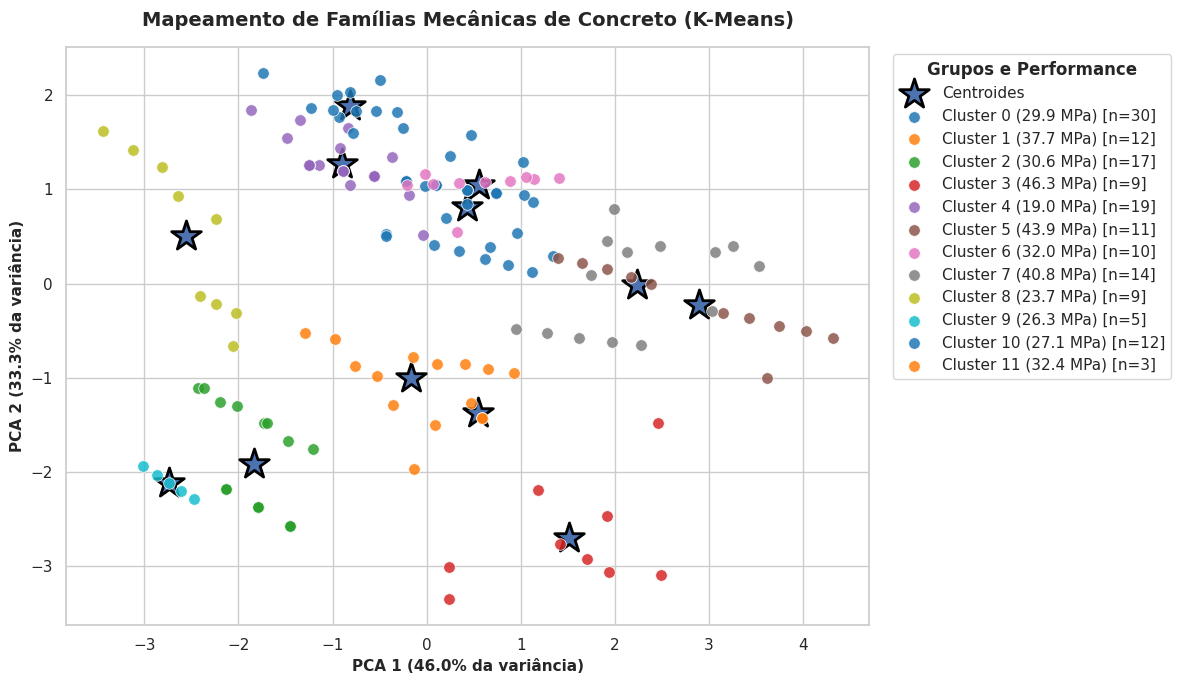

In [336]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot = df_mix.copy()
df_plot["PCA1"] = X_pca[:, 0]
df_plot["PCA2"] = X_pca[:, 1]

var_explicada = pca.explained_variance_ratio_ * 100

centroids = best_kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    marker='*',
    s=500,
    edgecolors='black',
    linewidths=2,
    label='Centroides'
)

clusters_validos = [c for c in sorted(df_plot["grupo_mecanico_cod"].unique()) if c != -1]
palette = sns.color_palette("tab10", n_colors=len(clusters_validos))

color_idx = 0
for cluster in sorted(df_plot["grupo_mecanico_cod"].unique()):
    subset = df_plot[df_plot["grupo_mecanico_cod"] == cluster]

    media_mpa = subset["Resistencia_Compressao_MPa"].mean()
    plt.scatter(
        subset["PCA1"], subset["PCA2"],
        color=palette[color_idx], alpha=0.85, edgecolors="w", s=70, linewidths=0.6,
        label=f"Cluster {cluster} ({media_mpa:.1f} MPa) [n={len(subset)}]"
    )
    color_idx += 1

plt.xlabel(f"PCA 1 ({var_explicada[0]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.ylabel(f"PCA 2 ({var_explicada[1]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.title("Mapeamento de Famílias Mecânicas de Concreto (K-Means)", fontsize=14, fontweight='bold', pad=15)

legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Grupos e Performance", frameon=True)
legend.get_title().set_fontweight('bold')

plt.tight_layout()
plt.show()

In [337]:
print(
    "Variância explicada:",
    pca.explained_variance_ratio_.sum()
)

Variância explicada: 0.7933430531889396


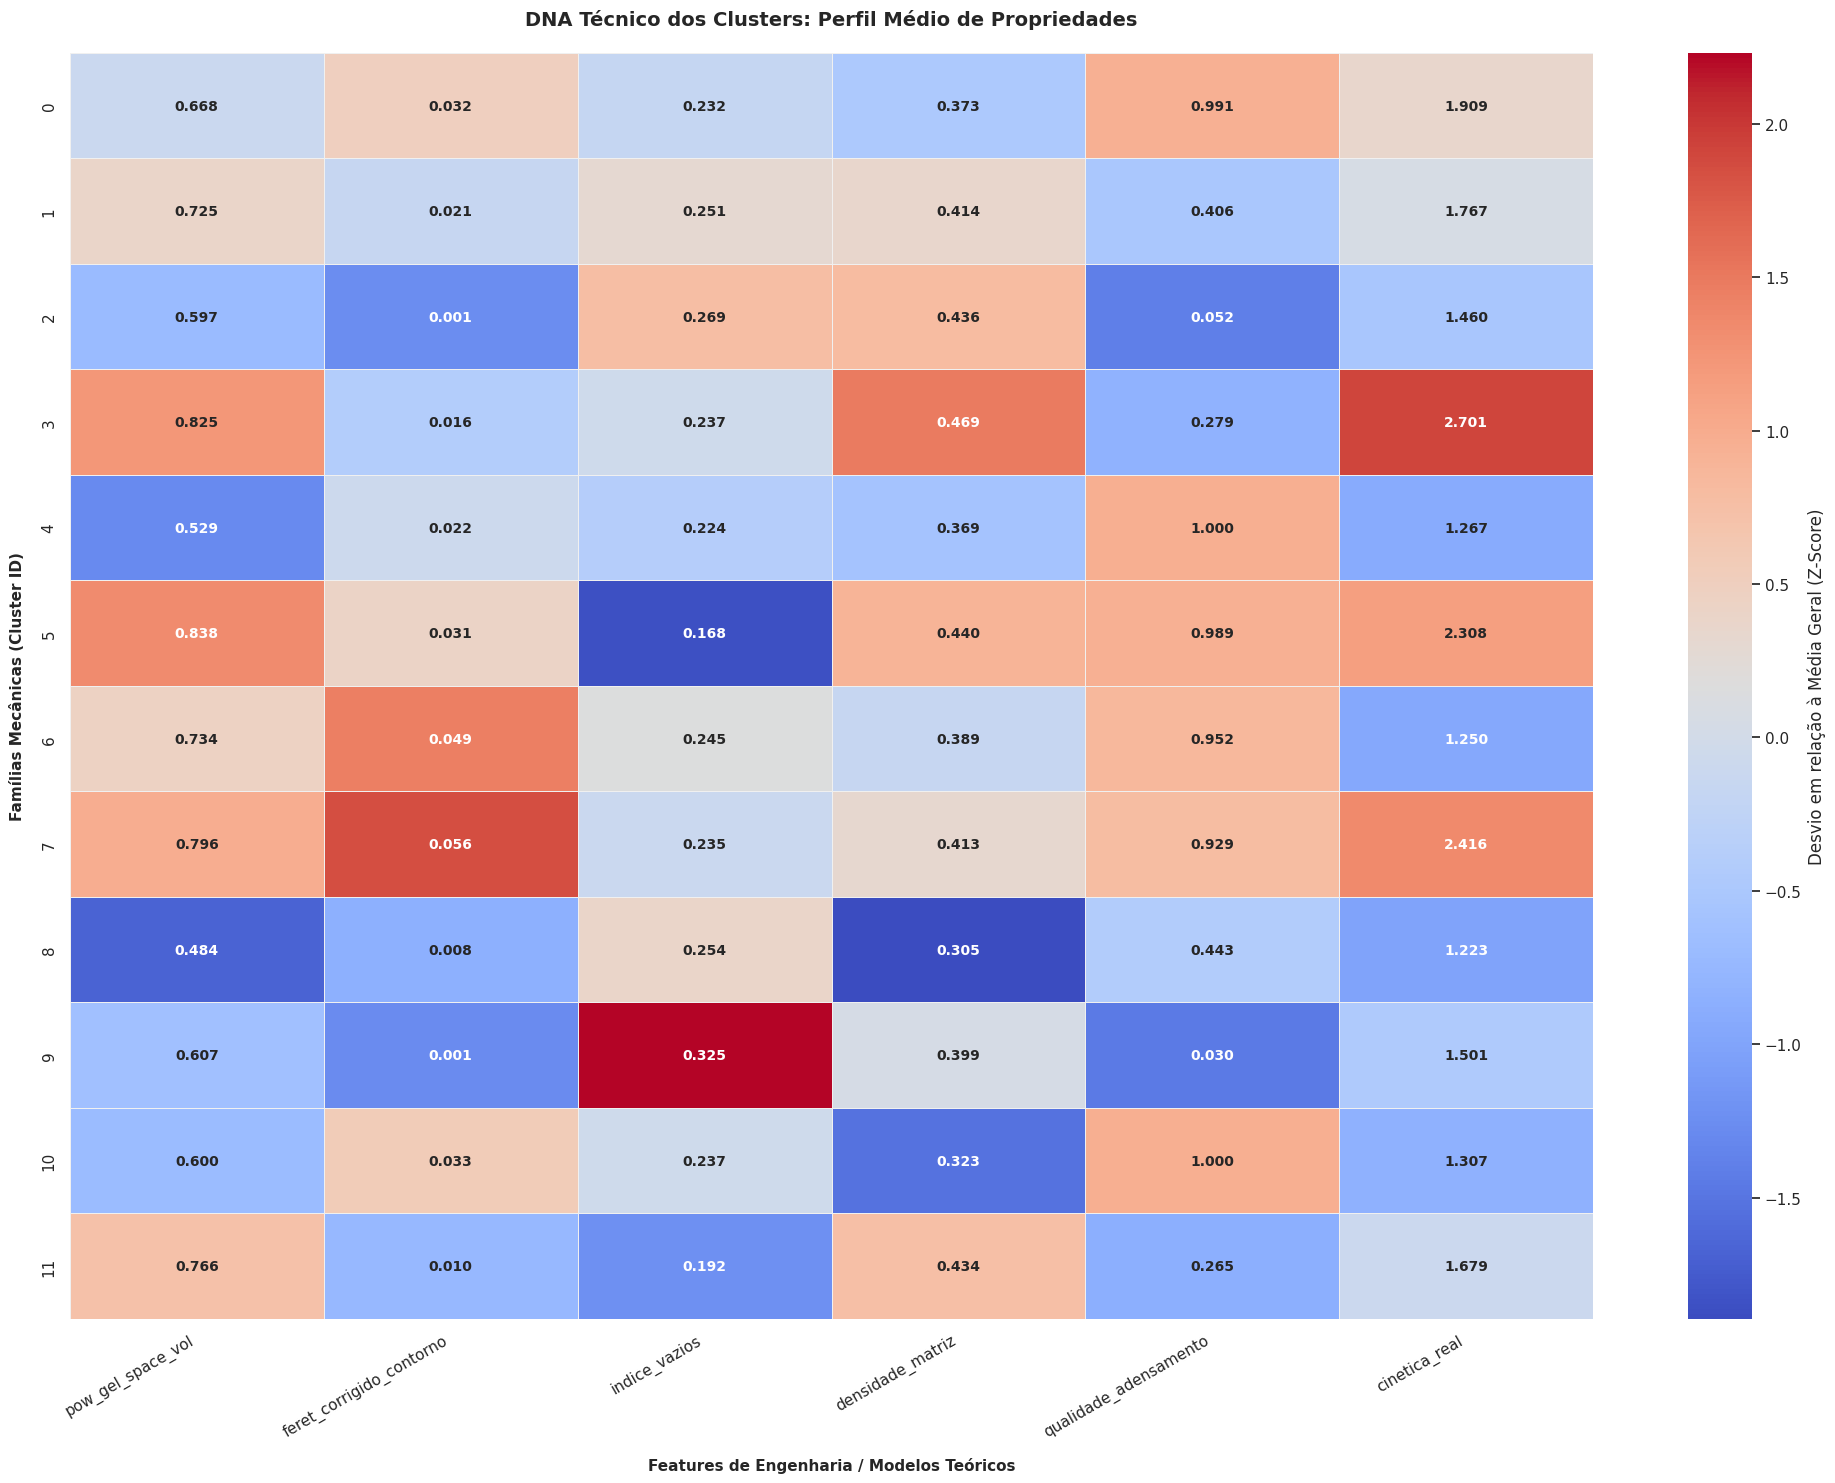

In [338]:
cluster_profile_raw = (
    df_resistencia
    .groupby("grupo_mecanico_cod")[colunas_cluster_derivadas]
    .mean()
)

# 3. O Pulo do Gato: Padronização apenas para a escala de CORES
# Isso diz quantos desvios padrões o cluster está acima (vermelho) ou abaixo (azul) da média geral
cluster_profile_scaled = (cluster_profile_raw - cluster_profile_raw.mean()) / cluster_profile_raw.std()

# 4. Configuração da figura (mais alta para caber os 18 clusters sem espremer)
plt.figure(figsize=(20, 15))

# 5. Construindo o Heatmap Inteligente
sns.heatmap(
    cluster_profile_scaled,
    annot=cluster_profile_raw.values, # <-- EXIBE OS VALORES REAIS
    fmt=".3f",                        # <-- Formata com 3 casas decimais
    cmap="coolwarm",                  # <-- Azul (Abaixo da média) | Vermelho (Acima da média)
    linewidths=0.7,                   # <-- Linha fina para separar os blocos
    linecolor="#F0F0F0",
    cbar_kws={'label': 'Desvio em relação à Média Geral (Z-Score)'},
    annot_kws={"size": 10, "weight": "semibold"} # Texto interno legível
)

# 6. Ajustes estéticos e labels
plt.title("DNA Técnico dos Clusters: Perfil Médio de Propriedades", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Features de Engenharia / Modelos Teóricos", fontsize=11, fontweight='bold', labelpad=12)
plt.ylabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=12)
plt.xticks(rotation=30, ha="right") # Rotaciona os nomes das colunas para não encavalar
plt.tight_layout()
plt.show()

/tmp/ipykernel_19118/3285360978.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


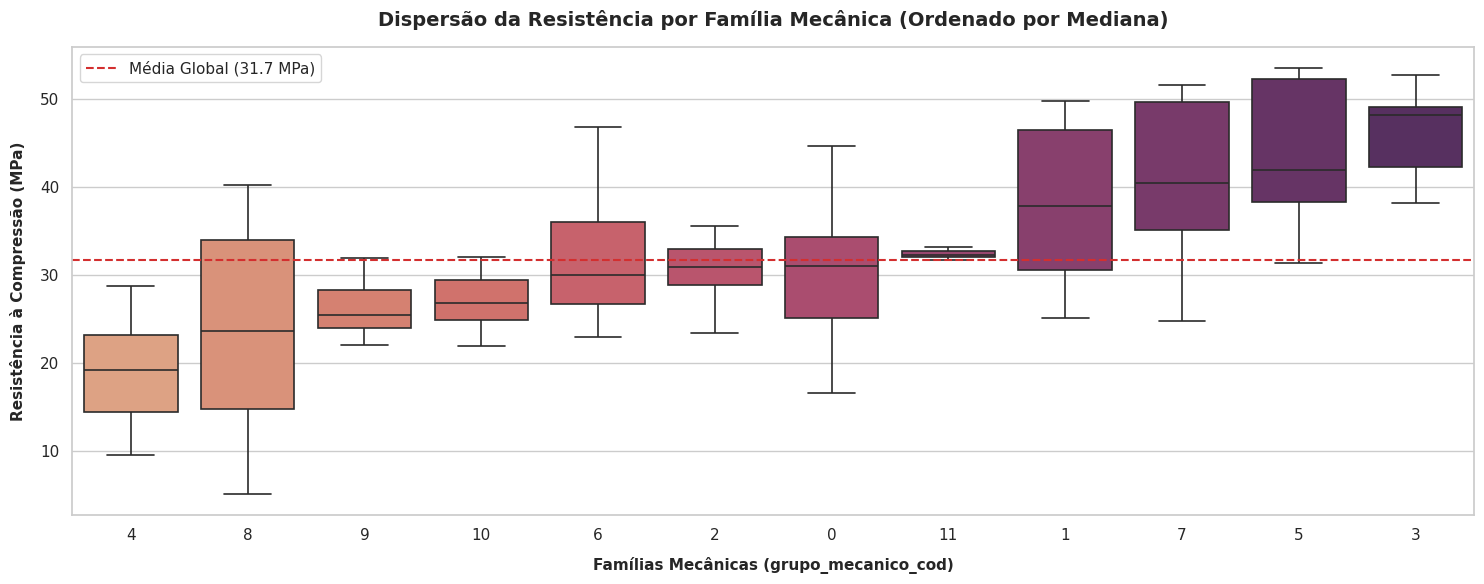

In [339]:
ordem_clusters = (
    df_mix
    .groupby("grupo_mecanico_cod")["Resistencia_Compressao_MPa"]
    .median()
    .sort_values()
    .index
)

# 2. Configuração estética do ambiente
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6)) # Aumentamos a largura para acomodar os 18 grupos sem espremer

# 3. Plot do Boxplot ordenado com uma paleta de degradê (flare ou viridis)
sns.boxplot(
    data=df_mix,
    x="grupo_mecanico_cod",
    y="Resistencia_Compressao_MPa",
    order=ordem_clusters,     # <-- Aplica a ordenação em escada
    palette="flare",          # <-- Cria um degradê suave acompanhando a subida
    linewidth=1.2,
    fliersize=4               # Tamanho dos outliers internos de cada cluster
)

# 4. Adiciona uma linha horizontal com a média global da base de dados
media_global = df_mix["Resistencia_Compressao_MPa"].mean()
plt.axhline(
    media_global,
    color="#D32F2F",
    linestyle="--",
    linewidth=1.5,
    label=f"Média Global ({media_global:.1f} MPa)"
)

# 5. Ajustes finais de polimento
plt.title("Dispersão da Resistência por Família Mecânica (Ordenado por Mediana)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Famílias Mecânicas (grupo_mecanico_cod)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Resistência à Compressão (MPa)", fontsize=11, fontweight='bold', labelpad=10)

# Como a figura está larga, rotação 0 ou 30 já é suficiente para leitura
plt.xticks(rotation=0)

plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [340]:
# Verificando se os clusters fazem sentido
analise_resistencia = df_resistencia.groupby('grupo_mecanico_cod')['Resistencia_Compressao_MPa'].agg(['mean', 'std', 'count', 'min', 'max'])
print(analise_resistencia)

                         mean        std  count    min   max
grupo_mecanico_cod                                          
0                   29.875463  11.637506    108  10.50  53.5
1                   37.579149  13.504472     47   9.00  61.3
2                   31.040580   8.395137     69  11.90  45.0
3                   46.311111   7.183064     27  32.80  57.5
4                   19.075000   8.742556     74   3.50  35.0
5                   43.600000  13.056606     53  14.00  67.0
6                   31.006923  10.105208     39   3.72  53.0
7                   41.841731  14.216244     52  16.00  71.0
8                   19.906383  12.847693     47   1.00  52.8
9                   26.342400  11.328031     25   6.70  44.4
10                  27.266562   7.176944     32   9.00  40.0
11                  32.436364  10.948632     11  17.60  46.5


In [341]:
df_resistencia.drop(columns=["ID_Mistura", "Tipo_Cimento_Classe"], inplace=True)

In [342]:
columns = df_resistencia.select_dtypes(include=['number']).columns

outliers_idx = {}
for column in columns:

    data = df_resistencia[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_idx[column] = data[(data < lower_bound) | (data > upper_bound)].index.tolist()

for column, idx in sorted(outliers_idx.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{column}: {len(idx)} outliers")

D_Max: 192 outliers
Massa_Esp_Filer_kg_m3: 180 outliers
aglomerante_total: 131 outliers
s_fib: 131 outliers
hasselman_resiliencia_agua: 92 outliers
vol_areia: 90 outliers
ryshkewitch_inicial: 89 outliers
schiller_inicial: 89 outliers
Filer_D50_um: 88 outliers
vol_ar_aprisionado: 78 outliers
porosidade_volumetrica_inicial: 78 outliers
ryshkewitch_linearizado: 78 outliers
hasselman_fator_inicial: 78 outliers
aci_desvio_cimento: 76 outliers
Metodo_Emp_Cod: 71 outliers
vol_po_total: 61 outliers
Superplastificante_kg_m3: 55 outliers
vol_sp: 55 outliers
indice_vazios: 53 outliers
ryshkewitch_real: 53 outliers
hasselman_fator_real: 53 outliers
schiller_real: 53 outliers
margem_colapso_schiller: 53 outliers
taxa_sp_aglomerante: 52 outliers
volume_materiais: 50 outliers
taxa_sp_cimento: 49 outliers
hasselman_cinetico: 49 outliers
ryshkewitch_cinetico: 41 outliers
Agregado_Miudo_Total_kg_m3: 40 outliers
finos_total: 35 outliers
range_granulometrico: 30 outliers
Agregado_Graudo_Total_kg_m3: 25 ou

In [343]:
counter = Counter()

for column, idx_list in outliers_idx.items():
    counter.update(idx_list)

outliers_comuns = pd.DataFrame(
    counter.items(),
    columns=["idx", "n_outlier_cols"]
).sort_values(
    "n_outlier_cols",
    ascending=False
)

outliers_comuns.value_counts("n_outlier_cols").sort_index()

,count
n_outlier_cols,
1,46
2,88
3,157
4,59
5,9
6,43
7,15
8,32
9,1


In [344]:
limite = np.percentile(outliers_comuns["n_outlier_cols"], 90)

In [345]:
df_resistencia.drop(index=outliers_comuns[outliers_comuns["n_outlier_cols"] > limite]["idx"], inplace=True)
df_resistencia.shape

(533, 94)

In [346]:
df_resistencia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 533 entries, 15 to 598
Data columns (total 94 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Autores/ano                      533 non-null    object 
 1   Finura_Cimento_Blaine_m2_kg      533 non-null    float64
 2   Cimento_kg_m3                    533 non-null    float64
 3   Filer_Calcario_kg_m3             533 non-null    float64
 4   Agua_kg_m3                       533 non-null    float64
 5   Agregado_Miudo_Total_kg_m3       533 non-null    float64
 6   Agregado_Graudo_Total_kg_m3      533 non-null    float64
 7   Superplastificante_kg_m3         533 non-null    float64
 8   Relacao_Agua_Cimento             533 non-null    float64
 9   ln_Idade                         533 non-null    float64
 10  Tipo_Molde_Cod                   533 non-null    int64  
 11  Metodo_Emp_Cod                   533 non-null    int64  
 12  Usa_SP                    

In [347]:

def check_gpu():
    try:
        # Tenta chamar o utilitário da NVIDIA. Oculta a saída no terminal.
        subprocess.check_output('nvidia-smi', stderr=subprocess.STDOUT)
        return True
    except (subprocess.CalledProcessError, FileNotFoundError):
        return False

HAS_GPU = check_gpu()

if HAS_GPU:
    print("🚀 GPU NVIDIA detectada! Modelos compatíveis utilizarão aceleração.")
else:
    print("🖥️ Nenhuma GPU detectada. Executando todos os modelos na CPU.")

# ==============================================================================
# 1. Preparando os dados e ISOLANDO o Grupo
# ==============================================================================
ALVO = 'Resistencia_Compressao_MPa'

whitelist_features = [
    'vol_cimento',
    'vol_filer',
    'Relacao_Agua_Aglomerante',
    'vol_sp'
]

grupos_isolamento = df_resistencia['Autores/ano'].copy()
whitelist_coluns = df_resistencia[whitelist_features].copy()
df_resistencia.drop(columns=whitelist_coluns.columns, inplace=True)
df_resistencia.drop(columns=['Autores/ano'], inplace=True)

X = df_resistencia.copy()
y = df_resistencia[ALVO]
X.drop(columns=[ALVO], inplace=True)

nome_modelo = "Ridge"

# ==============================================================================
# 2. Configurando Parâmetros Dinâmicos e o Dicionário de Modelos
# ==============================================================================

# Dicionários base para os modelos que suportam GPU
xgb_params = {"random_state": 42, "n_jobs": -1}
cat_params = {"random_state": 42, "verbose": False}

if HAS_GPU:
    # Nota: Em versões muito recentes do XGBoost (>2.0), usa-se device="cuda".
    # Em versões padrão/antigas, tree_method="gpu_hist" é o comando correto.
    xgb_params["tree_method"] = "gpu_hist"

    cat_params["task_type"] = "GPU"
    cat_params["devices"] = "0"

modelos = {
    # Desempacotamos os dicionários dinâmicos aqui usando **
    "XGBoost": XGBRegressor(**xgb_params),
    "CatBoost": CatBoostRegressor(**cat_params),

    # Modelos Scikit-Learn e outros (Rodam 100% na CPU)
    "HGBR": GradientBoostingRegressor(random_state=42),
    "RF": RandomForestRegressor(random_state=42, n_jobs=-1),
    "NGBoost": NGBRegressor(random_state=42, verbose=False),
    "Lasso": Lasso(random_state=42, max_iter=10000),
    "Ridge": Ridge(random_state=42, max_iter=10000),
    "ElasticNet": ElasticNet(random_state=42, max_iter=10000),
    "RL": LinearRegression(n_jobs=-1),
    "MLP": MLPRegressor(
        activation="tanh",
        solver="lbfgs",
        max_iter=9000,
        random_state=42
    )
}

need_scaler = nome_modelo in ["Lasso", "Ridge", "ElasticNet", "RL", "MLP"]

# ==============================================================================
# 3. Tratamentos Específicos
# ==============================================================================
if nome_modelo == "HGBR":
    X.fillna(X.select_dtypes(include='number').mean(), inplace=True)

if nome_modelo == "XGBoost":
    categorical_cols = X.select_dtypes(include=['object']).columns
    X.drop(columns=categorical_cols, inplace=True)

estimador = modelos[nome_modelo]

🖥️ Nenhuma GPU detectada. Executando todos os modelos na CPU.


## Colunas que vão passar por seleção de features

In [348]:
df_resistencia.columns

Index(['Finura_Cimento_Blaine_m2_kg', 'Cimento_kg_m3', 'Filer_Calcario_kg_m3',
       'Agua_kg_m3', 'Agregado_Miudo_Total_kg_m3',
       'Agregado_Graudo_Total_kg_m3', 'Superplastificante_kg_m3',
       'Relacao_Agua_Cimento', 'ln_Idade', 'Tipo_Molde_Cod', 'Metodo_Emp_Cod',
       'Usa_SP', 'Classe_Cim_OpA', 'Filer_D50_um', 'D_Max',
       'Resistencia_Compressao_MPa', 'cod_classe', 'familia_cod', 'f',
       'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Areia_kg_m3',
       'Massa_Esp_Brita_kg_m3', 'Massa_Esp_Filer_kg_m3', 'vol_agua',
       'vol_areia', 'vol_brita', 'volume_materiais', 'vol_ar_aprisionado',
       'porosidade_volumetrica_inicial', 'vol_solidos_totais', 'indice_vazios',
       'vol_agregados', 'vol_pasta', 'vol_po_total', 'pasta_agregado',
       'fracao_agregados', 'aglomerante_total', 'inv_a_c', 'fator_agua_po',
       'finos_total', 'taxa_filer_inerte', 'taxa_sp_cimento',
       'taxa_sp_aglomerante', 'range_granulometrico', 'idade_fator_agua',
       'parametro_feret', 'i

## Colunas Fixas da Base de dados

In [349]:
whitelist_coluns.columns

Index(['vol_cimento', 'vol_filer', 'Relacao_Agua_Aglomerante', 'vol_sp'], dtype='object')

In [350]:
# 1. Função isolada para rodar em paralelo
def avaliar_candidato(feat, features_atuais, X, y, cv_splits, estimador, need_scaler):
    feats_teste = [f for f in features_atuais if f != feat]
    fold_rmse, fold_mae, fold_mape, fold_r2 = [], [], [], []

    for train_idx, test_idx in cv_splits:
        X_train = X.iloc[train_idx][feats_teste]
        X_test = X.iloc[test_idx][feats_teste]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model = clone(estimador)

        if need_scaler:
            scaler_fold = StandardScaler()
            X_train = scaler_fold.fit_transform(X_train)
            X_test = scaler_fold.transform(X_test)

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        fold_rmse.append(root_mean_squared_error(y_test, pred))
        fold_mae.append(mean_absolute_error(y_test, pred))
        fold_mape.append(mean_absolute_percentage_error(y_test, pred))
        fold_r2.append(r2_score(y_test, pred))

    return {
        "feature_removida": feat,
        "rmse_mean": np.mean(fold_rmse),
        "mae_mean": np.mean(fold_mae),
        "mape_mean": np.mean(fold_mape),
        "r2_mean": np.mean(fold_r2),
        "rmse_std": np.std(fold_rmse),
        "features_restantes": feats_teste
    }

In [351]:
X.columns

Index(['Finura_Cimento_Blaine_m2_kg', 'Cimento_kg_m3', 'Filer_Calcario_kg_m3',
       'Agua_kg_m3', 'Agregado_Miudo_Total_kg_m3',
       'Agregado_Graudo_Total_kg_m3', 'Superplastificante_kg_m3',
       'Relacao_Agua_Cimento', 'ln_Idade', 'Tipo_Molde_Cod', 'Metodo_Emp_Cod',
       'Usa_SP', 'Classe_Cim_OpA', 'Filer_D50_um', 'D_Max', 'cod_classe',
       'familia_cod', 'f', 'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Areia_kg_m3',
       'Massa_Esp_Brita_kg_m3', 'Massa_Esp_Filer_kg_m3', 'vol_agua',
       'vol_areia', 'vol_brita', 'volume_materiais', 'vol_ar_aprisionado',
       'porosidade_volumetrica_inicial', 'vol_solidos_totais', 'indice_vazios',
       'vol_agregados', 'vol_pasta', 'vol_po_total', 'pasta_agregado',
       'fracao_agregados', 'aglomerante_total', 'inv_a_c', 'fator_agua_po',
       'finos_total', 'taxa_filer_inerte', 'taxa_sp_cimento',
       'taxa_sp_aglomerante', 'range_granulometrico', 'idade_fator_agua',
       'parametro_feret', 'idade_feret', 'saturacao_pasta',
     

In [352]:
for col in X.columns:
    if X[col].isna().sum() > 0:
        print(f"{col}: {X[col].dtype}, Nulos: {X[col].isna().sum()}")

f: float64, Nulos: 436


In [353]:
# =====================================================================
# 2. Execução Principal
# =====================================================================

usar_paralelismo_cpu = not (HAS_GPU and nome_modelo in ["XGBoost", "CatBoost"])

if usar_paralelismo_cpu:
    n_cores = multiprocessing.cpu_count()
    print(f"⏳ Rodando SBS para: {nome_modelo} | Paralelizado na CPU ({n_cores} núcleos)...")
else:
    print(f"⏳ Rodando SBS para: {nome_modelo} | Sequencial na GPU (Aceleração nativa)...")

n_splits = min(5, grupos_isolamento.nunique())
gkf = GroupKFold(n_splits=n_splits)

features_atuais = list(X.columns)

best_rmse = np.inf
best_features = features_atuais.copy()
best_metrics = {}
historico = []

cv_splits = list(gkf.split(X, y, groups=grupos_isolamento))

# ---------------------------------------------------------------------
# INICIANDO A BARRA DE PROGRESSO PRINCIPAL
# ---------------------------------------------------------------------
total_iteracoes = len(features_atuais) - 1
pbar_principal = tqdm(
    total=total_iteracoes,
    desc=f"Progresso Geral ({nome_modelo})",
    dynamic_ncols=True,
    colour="#00ff00"
)

while len(features_atuais) > 1:

    if usar_paralelismo_cpu:
        candidatos = Parallel(n_jobs=-1)(
            delayed(avaliar_candidato)(
                feat, features_atuais, X, y, cv_splits, estimador, need_scaler
            ) for feat in features_atuais
        )
    else:
        candidatos = [
            avaliar_candidato(feat, features_atuais, X, y, cv_splits, estimador, need_scaler)
            for feat in tqdm(
                features_atuais,
                desc=f"Avaliando {len(features_atuais)} features...",
                leave=False,
                colour="#00bfff"
            )
        ]

    melhor_iteracao = min(candidatos, key=lambda x: x["rmse_mean"])
    features_atuais = melhor_iteracao["features_restantes"]

    rmse_atual = melhor_iteracao["rmse_mean"]
    mae_atual = melhor_iteracao["mae_mean"]
    mape_atual = melhor_iteracao["mape_mean"]
    r2_atual = melhor_iteracao["r2_mean"]

    historico.append({
        "n_features": len(features_atuais),
        "feature_removida": melhor_iteracao["feature_removida"],
        "rmse_mean": rmse_atual,
        "mae_mean": mae_atual,
        "mape_mean": mape_atual,
        "r2_mean": r2_atual,
        "rmse_std": melhor_iteracao["rmse_std"],
        "features": features_atuais.copy()
    })

    # -----------------------------------------------------------------
    # TQDM.WRITE SUBSTITUINDO O PRINT COMUM
    # -----------------------------------------------------------------
    tqdm.write(
        f"✅ {len(features_atuais):2d} features restantes | "
        f"Removeu: '{melhor_iteracao['feature_removida'][:15]}' | "
        f"RMSE: {rmse_atual:.4f} | MAE: {mae_atual:.4f} | "
        f"MAPE: {mape_atual:.4f} | R2: {r2_atual:.4f}"
    )

    if rmse_atual <= best_rmse:
        best_rmse = rmse_atual
        best_features = features_atuais.copy()
        best_metrics = {
            "RMSE": rmse_atual,
            "MAE": mae_atual,
            "MAPE": mape_atual,
            "R2": r2_atual
        }

    # Avança a barra de progresso principal
    pbar_principal.update(1)

# Fecha a barra principal quando o loop termina
pbar_principal.close()

print("\n" + "="*50)
print("🏆 Melhor solução encontrada (baseada no menor RMSE):")
print(f"Número de features = {len(best_features)}")
print(f"Métricas Globais: RMSE = {best_metrics.get('RMSE', 0):.4f} | MAE = {best_metrics.get('MAE', 0):.4f} | MAPE = {best_metrics.get('MAPE', 0):.4f} | R2 = {best_metrics.get('R2', 0):.4f}")
print("Features Selecionadas:")
print(best_features)

⏳ Rodando SBS para: Ridge | Paralelizado na CPU (2 núcleos)...


Progresso Geral (Ridge):   0%|          | 0/87 [00:00<?, ?it/s]

ValueError: Input X contains NaN.
Ridge does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## Features sobreviventes da seleção de features

In [ ]:
# DF final
df_final = pd.concat([df_resistencia[best_features], y, grupos_isolamento, whitelist_coluns], axis=1)

df_final.columns, df_final.shape

(Index(['Finura_Cimento_Blaine_m2_kg', 'Cimento_kg_m3', 'Filer_Calcario_kg_m3',
        'Agregado_Graudo_Total_kg_m3', 'Usa_SP', 'D_Max', 'cod_classe',
        'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Brita_kg_m3', 'vol_brita',
        'porosidade_volumetrica_inicial', 'vol_po_total', 'pasta_agregado',
        'aglomerante_total', 'finos_total', 'range_granulometrico',
        'parametro_feret', 'saturacao_pasta', 'qualidade_adensamento',
        'fator_resistencia_rocha', 'parametro_feret_filer_k5',
        'idade_parametro_feret_filer_k5', 'pow_cubo_vol', 'razao_powers_feret',
        'ryshkewitch_real', 'ryshkewitch_linearizado',
        'hasselman_fator_inicial', 'hasselman_fator_real', 'hasselman_cinetico',
        'schiller_real', 'aci_209_fator_tempo', 's_fib', 'pasta_agregado_fino',
        'densidade_matriz', 'Resistencia_Compressao_MPa', 'Autores/ano',
        'vol_cimento', 'vol_filer', 'Relacao_Agua_Aglomerante', 'vol_sp'],
       dtype='object'),
 (531, 40))

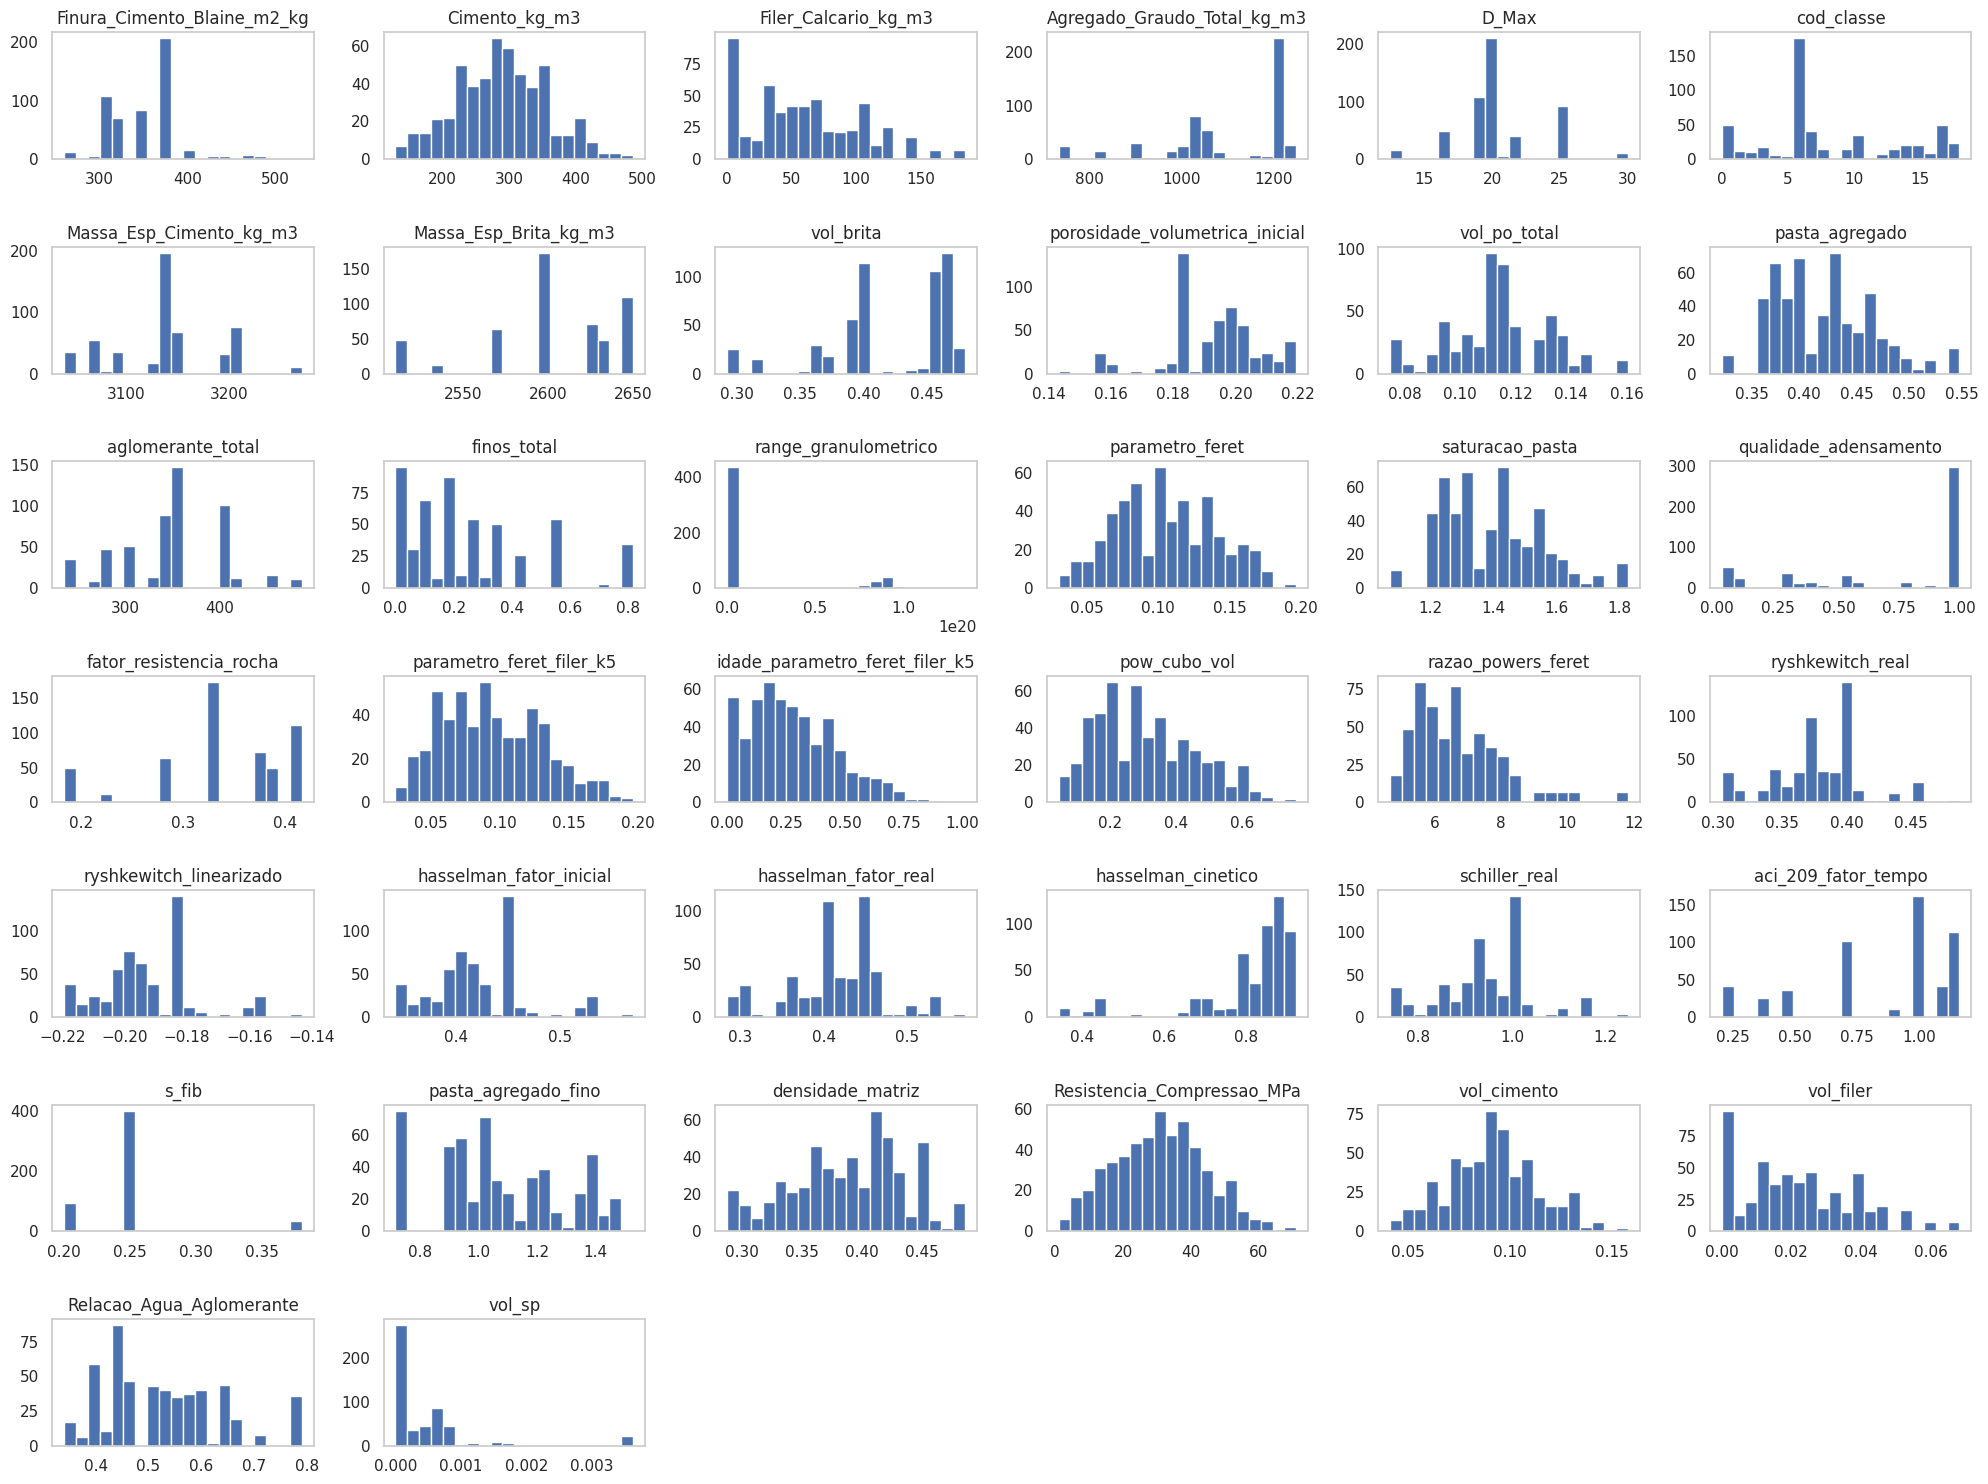

In [ ]:
df_final.hist(bins=20, figsize=(20, 15), grid=False)
plt.tight_layout()
plt.show()

In [ ]:
df_final.to_pickle(os.path.join(base_dir, f'df_resistencia_{nome_modelo}.pkl'))

In [ ]:
# Limites de range das váriaveis numéricas
limites = {}
for column in df_resistencia.select_dtypes(include=['number']).columns:
    data = df_resistencia[column]
    lower_bound = data.min()
    upper_bound = data.max()
    limites[column] = (lower_bound, upper_bound)
print("Limites de range das variáveis numéricas:")
for column, (lower, upper) in limites.items():
    print(f"{column}: [{lower:.4f}, {upper:.4f}]")

Limites de range das variáveis numéricas:
Finura_Cimento_Blaine_m2_kg: [260.0000, 530.0000]
Cimento_kg_m3: [129.3000, 487.0000]
Filer_Calcario_kg_m3: [0.0000, 184.5000]
Agua_kg_m3: [134.0000, 205.0000]
Agregado_Miudo_Total_kg_m3: [595.0000, 1074.0000]
Agregado_Graudo_Total_kg_m3: [732.4000, 1249.0000]
Superplastificante_kg_m3: [0.0000, 4.0000]
Relacao_Agua_Cimento: [0.3600, 1.4300]
ln_Idade: [0.0000, 5.8999]
Tipo_Molde_Cod: [1.0000, 5.0000]
Metodo_Emp_Cod: [0.0000, 1.0000]
Classe_Cim_OpA: [32.0000, 63.0000]
Filer_D50_um: [0.0000, 72.0000]
D_Max: [12.5000, 30.0000]
Resistencia_Compressao_MPa: [1.0000, 71.0000]
cod_classe: [0.0000, 18.0000]
familia_cod: [0.0000, 7.0000]
Massa_Esp_Cimento_kg_m3: [3040.0000, 3270.0000]
Massa_Esp_Areia_kg_m3: [2570.0000, 2700.0000]
Massa_Esp_Brita_kg_m3: [2510.0000, 2650.0000]
Massa_Esp_Filer_kg_m3: [2550.0000, 2920.0000]
vol_agua: [0.1340, 0.2050]
vol_areia: [0.2215, 0.4086]
vol_brita: [0.2918, 0.4804]
volume_materiais: [0.9195, 1.0479]
vol_ar_aprisionado: